<a href="https://colab.research.google.com/github/mashac136/RealTimeMachineLearning/blob/main/hw4_transformers_MarlyAshac!.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
#1

# imports and environment Setup

# PyTorch imports
import torch                      # Main PyTorch library
import torch.nn as nn             # Neural network layers
import torch.nn.functional as F   # Functional ops
from torch.utils.data import Dataset, DataLoader  # for batching our char sequences

import numpy as np                # numerical operations (array handling)
import math                       # for sin/cos and scaling factors
import time
import random
import matplotlib.pyplot as plt   # for plotting loss curves later

#  fixed seed so results are consistent across runs
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)  # ensures GPU ops are also seeded (Kaggle/Colab both use CUDA GPUs)

# device setup: automatically use GPU if available -otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# print GPU name to confirm which GPU we got
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla T4


In [6]:
#2
# load text data and build character vocabulary (Problem 1)

# paragraph given in the assignment prompt for Problem 1
# mirrors HW2's approach: a fixed short text sequence, NOT Tiny Shakespeare.
# (tiny shakespeare reserved for Problem 2)
text = """Next character prediction is a fundamental task in the field of natural language processing (NLP) that involves predicting the next character in a sequence of text based on the characters that precede it. This task is essential for various applications, including text auto-completion, spell checking, and even in the development of sophisticated AI models capable of generating human-like text.

At its core, next character prediction relies on statistical models or deep learning algorithms to analyze a given sequence of text and predict which character is most likely to follow. These predictions are based on patterns and relationships learned from large datasets of text during the training phase of the model.

One of the most popular approaches to next character prediction involves the use of Recurrent Neural Networks (RNNs), and more specifically, a variant called Long Short-Term Memory (LSTM) networks. RNNs are particularly well-suited for sequential data like text, as they can maintain information in 'memory' about previous characters to inform the prediction of the next character. LSTM networks enhance this capability by being able to remember long-term dependencies, making them even more effective for next character prediction tasks.

Training a model for next character prediction involves feeding it large amounts of text data, allowing it to learn the probability of each character's appearance following a sequence of characters. During this training process, the model adjusts its parameters to minimize the difference between its predictions and the actual outcomes, thus improving its predictive accuracy over time.

Once trained, the model can be used to predict the next character in a given piece of text by considering the sequence of characters that precede it. This can enhance user experience in text editing software, improve efficiency in coding environments with auto-completion features, and enable more natural interactions with AI-based chatbots and virtual assistants.

In summary, next character prediction plays a crucial role in enhancing the capabilities of various NLP applications, making text-based interactions more efficient, accurate, and human-like. Through the use of advanced machine learning models like RNNs and LSTMs, next character prediction continues to evolve, opening new possibilities for the future of text-based technology."""

# sanity check on the text
print(f"Total characters in text: {len(text)}")
# in HW2 this same paragraph had 2,391 characters and 45 unique characters.
# print len(text) here to confirm we match that number before moving forward.

# build the character vocabulary
# sorted() ensures a deterministic order every time we run this
chars = sorted(list(set(text)))
vocab_size = len(chars)
print(f"Unique characters (vocab size): {vocab_size}")
# this should match HW2's reported 45 unique characters.

# create mapping dictionaries: char to integer index, and integer index to char
# RNNs work on integer token IDs - not raw characters,
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}

# encode/decode helper functions
def encode(s):
    """Convert a string into a list of integer character indices."""
    return [char_to_idx[c] for c in s]

def decode(indices):
    """Convert a list (or tensor) of integer indices back into a string."""
    return ''.join([idx_to_char[int(i)] for i in indices])

# encode the entire text into a tensor of integers
# dtype=torch.long is required because embedding layers expect integer (long) indices
data = torch.tensor(encode(text), dtype=torch.long)
print(f"Encoded data shape: {data.shape}")

# encode then decode a short snippet - should match original ---
sample = text[:30]
print(f"Original : {sample}")
print(f"Decoded  : {decode(encode(sample))}")

Total characters in text: 2391
Unique characters (vocab size): 45
Encoded data shape: torch.Size([2391])
Original : Next character prediction is a
Decoded  : Next character prediction is a


In [7]:

# 3: Sliding-Window Dataset for Next-Character Prediction

class CharSequenceDataset(Dataset):
    """
    Builds (input, target) pairs for next-character prediction using a sliding window.

    For a given seq_len, each training example is:
      input  = characters[i : i+seq_len]        (a chunk of seq_len characters)
      target = characters[i+1 : i+seq_len+1]     (the same chunk, shifted by 1 char)

    This shifted-by-one setup means the model learns, at every position in the
    sequence, to predict the next character given everything before it.
    This matches the standard approach used in HW2 for RNN/LSTM/GRU training.
    """

    def __init__(self, data, seq_len):
        self.data = data
        self.seq_len = seq_len

    def __len__(self):
        return len(self.data) - self.seq_len

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.seq_len]
        y = self.data[idx + 1 : idx + self.seq_len + 1]
        return x, y


def make_dataloaders(data, seq_len, batch_size=64, val_split=0.2):
    """
    Splits the encoded data 80/20 into train/val (matching HW2's split),
    wraps each half in a CharSequenceDataset, and returns DataLoaders.
    """
    split_idx = int(len(data) * (1 - val_split))
    train_data = data[:split_idx]
    val_data = data[split_idx:]

    train_dataset = CharSequenceDataset(train_data, seq_len)
    val_dataset = CharSequenceDataset(val_data, seq_len)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader


# sanity check with seq_len=10
test_train_loader, test_val_loader = make_dataloaders(data, seq_len=10)
xb, yb = next(iter(test_train_loader))
print(f"Sample input batch shape:  {xb.shape}")
print(f"Sample target batch shape: {yb.shape}")
print(f"Train batches: {len(test_train_loader)} | Val batches: {len(test_val_loader)}")

print(f"\nExample input : {decode(xb[0])}")
print(f"Example target: {decode(yb[0])}")

Sample input batch shape:  torch.Size([64, 10])
Sample target batch shape: torch.Size([64, 10])
Train batches: 30 | Val batches: 8

Example input : works enha
Example target: orks enhan


In [8]:

#4
# positional encoding module

class PositionalEncoding(nn.Module):
    """
    Transformers have no built-in notion of sequence order (unlike RNNs, which
    process tokens one step at a time). To fix this, we inject information about
    each token's position in the sequence using fixed sinusoidal functions,
    as introduced in the original "Attention Is All You Need" paper.

    We add this positional encoding directly to the token embeddings before
    feeding them into the transformer blocks.
    """

    def __init__(self, embed_size, max_len=5000):
        super().__init__()
        # embed_size: dimensionality of our token embeddings
        # max_len: maximum sequence length we'll ever need to support

        # create a matrix to hold positional encodings: shape [max_len, embed_size]
        pe = torch.zeros(max_len, embed_size)

        # position indices: [0, 1, 2, ..., max_len-1], shape [max_len, 1] ---
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)

        # compute the division term
        # different "wavelengths" of position
        div_term = torch.exp(
            torch.arange(0, embed_size, 2).float() * (-math.log(10000.0) / embed_size)
        )

        # apply sin to even indices, cos to odd indices
        pe[:, 0::2] = torch.sin(position * div_term)  # even
        pe[:, 1::2] = torch.cos(position * div_term)  # odd

        # add a batch dimension: shape becomes [1, max_len, embed_size]
        pe = pe.unsqueeze(0)

        # --- Register as a buffer (not a learnable parameter, but moves with .to(device)) ---
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x shape: [batch_size, seq_len, embed_size]
        # slice pe to match the current sequence length, then add it elementwise
        seq_len = x.size(1)
        x = x + self.pe[:, :seq_len, :]
        return x


# sanity check
pos_enc = PositionalEncoding(embed_size=64)
dummy_input = torch.zeros(2, 10, 64)  # [batch=2, seq_len=10, embed_size=64]
output = pos_enc(dummy_input)
print(f"Input shape:  {dummy_input.shape}")
print(f"Output shape: {output.shape}")  # Should be unchanged: [2, 10, 64]
print(f"Positional encoding added successfully: {not torch.equal(dummy_input, output)}")

Input shape:  torch.Size([2, 10, 64])
Output shape: torch.Size([2, 10, 64])
Positional encoding added successfully: True


In [9]:
#5

# character-Level transformer

class CharTransformer(nn.Module):
    """
    A small transformer encoder for next-character prediction.

    Architecture:
      1. Token embedding: maps character indices -> dense vectors
      2. Positional encoding: injects order information (added to embeddings)
      3. Stack of transformer encoder blocks (self-attention + feedforward)
      4. Output projection: maps back from embed_size -> vocab_size (logits over chars)

    We use a causal (look-ahead) mask so that when predicting character at
    position i, the model can only attend to characters at positions <= i.
    Without this mask, the model could "cheat" by looking at future characters,
    which defeats the purpose of next-character prediction.
    """

    def __init__(self, vocab_size, embed_size=64, num_heads=2, num_layers=2,
                 ff_hidden_size=256, dropout=0.1, max_len=5000):
        super().__init__()
        # vocab_size: number of unique characters (45 for Problem 1)
        # embed_size: dimensionality of token embeddings
        # num_heads: number of attention heads per transformer block
        # num_layers: number of stacked transformer encoder blocks
        # ff_hidden_size: hidden dimension of the feedforward network inside each block
        # dropout: dropout probability for regularization

        self.embed_size = embed_size

        # token embedding layer: converts char indices to embed_size vectors=
        self.token_embedding = nn.Embedding(vocab_size, embed_size)

        # positional encoding (defined in last cell)
        self.pos_encoding = PositionalEncoding(embed_size, max_len=max_len)

        # dropout applied after adding positional encoding
        self.dropout = nn.Dropout(dropout)

        # build one transformer encoder layer, then stack num_layers of them
        # batch_first=True means our tensors are [batch, seq_len, embed_size]
        # instead of PyTorch's older default [seq_len, batch, embed_size]
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_size,
            nhead=num_heads,
            dim_feedforward=ff_hidden_size,
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # output projection: maps final hidden states back to vocab-size logits
        self.output_proj = nn.Linear(embed_size, vocab_size)

    def _generate_causal_mask(self, seq_len, device):
        """
        Builds a causal mask of shape [seq_len, seq_len] where position i can
        attend to positions 0..i but NOT i+1..seq_len-1 (i.e., no peeking ahead).

        PyTorch's transformer expects the mask to have -inf in disallowed
        positions and 0 in allowed positions (added to attention scores
        before softmax).
        """
        mask = torch.triu(torch.ones(seq_len, seq_len, device=device), diagonal=1)
        mask = mask.masked_fill(mask == 1, float('-inf'))
        return mask

    def forward(self, x):
        # x shape: [batch_size, seq_len] — integer character indices
        batch_size, seq_len = x.shape

        # embed tokens, then scale by sqrt
        x = self.token_embedding(x) * math.sqrt(self.embed_size)  # [batch, seq_len, embed_size]

        # add positional encoding
        x = self.pos_encoding(x)
        x = self.dropout(x)

        # build causal mask so model can't see future characters
        causal_mask = self._generate_causal_mask(seq_len, x.device)

        # pass through transformer encoder blocks
        x = self.transformer_encoder(x, mask=causal_mask)  # [batch, seq_len, embed_size]

        # project to vocabulary size
        logits = self.output_proj(x)  # [batch, seq_len, vocab_size]

        return logits


# build a model and run one forward pass
test_model = CharTransformer(vocab_size=vocab_size, embed_size=64, num_heads=2, num_layers=2)
test_model = test_model.to(device)

xb_test, yb_test = next(iter(test_train_loader))
xb_test = xb_test.to(device)

logits = test_model(xb_test)
print(f"Input shape:  {xb_test.shape}")             # [batch, seq_len]
print(f"Output shape: {logits.shape}")               # [batch, seq_len, vocab_size]

# count total trainable parameters
num_params = sum(p.numel() for p in test_model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {num_params:,}")

Input shape:  torch.Size([64, 10])
Output shape: torch.Size([64, 10, 45])
Total trainable parameters: 105,773


In [10]:
# training loop

def train_model(model, train_loader, val_loader, num_epochs=20, learning_rate=0.003, device=device):
    """
    Generic training loop for the CharTransformer model. Mirrors the HW2 setup
    (Adam optimizer, cross-entropy loss) so results are directly comparable.

    Returns a history dict containing per-epoch train loss and val accuracy,
    plus total training time, so we can build comparison tables/plots later.
    """

    # loss function
    criterion = nn.CrossEntropyLoss()

    # optimizer: Adam - same choice as HW2
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    # history tracking for plotting/comparison later
    history = {
        'train_loss': [],
        'val_loss': [],
        'val_acc': []
    }

    # start timing the full training run
    start_time = time.time()

    for epoch in range(num_epochs):

        # training phase

        model.train()  # enables dropout
        total_train_loss = 0.0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)  # move batch to GPU

            optimizer.zero_grad()  # clear gradients from previous step

            logits = model(xb)  # [batch, seq_len, vocab_size]

            # reshape for CrossEntropyLoss
            loss = criterion(logits.reshape(-1, vocab_size), yb.reshape(-1))

            loss.backward()   # compute gradients
            optimizer.step()  # update weights

            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        history['train_loss'].append(avg_train_loss)

        # validation phase

        model.eval()  # disables dropout
        total_val_loss = 0.0
        correct_preds = 0
        total_preds = 0

        with torch.no_grad():  # no gradient tracking needed for validation
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)

                logits = model(xb)
                loss = criterion(logits.reshape(-1, vocab_size), yb.reshape(-1))
                total_val_loss += loss.item()

                # compute accuracy
                preds = logits.argmax(dim=-1)  # [batch, seq_len] — most likely char at each position
                correct_preds += (preds == yb).sum().item()
                total_preds += yb.numel()

        avg_val_loss = total_val_loss / len(val_loader)
        val_accuracy = 100.0 * correct_preds / total_preds

        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(val_accuracy)

        # print progress every few epochs to keep output readable
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{num_epochs} | "
                  f"Train Loss: {avg_train_loss:.4f} | "
                  f"Val Loss: {avg_val_loss:.4f} | "
                  f"Val Acc: {val_accuracy:.2f}%")

    # total training time in seconds
    total_time = time.time() - start_time
    history['total_time'] = total_time

    print(f"\nTraining complete in {total_time:.2f}s")
    print(f"Final Train Loss: {history['train_loss'][-1]:.4f} | "
          f"Final Val Acc: {history['val_acc'][-1]:.2f}%")

    return history

In [11]:
print(train_model)

<function train_model at 0x7808ae2ccb80>


In [12]:
# train transformer on sequence length 10

# set the sequence length for this run
SEQ_LEN_10 = 10

# build train/val DataLoaders for this sequence length -
# (Using the make_dataloaders function from cell 3, batch_size=64 to match HW2)
train_loader_10, val_loader_10 = make_dataloaders(data, seq_len=SEQ_LEN_10, batch_size=64)

#  fresh transformer model
#  same base config throughout Problem 1: embed_size=64, 2 heads, 2 layers
#  HW2's RNN/LSTM/GRU also used a fairly small hidden size of 128
model_seq10 = CharTransformer(
    vocab_size=vocab_size,
    embed_size=64,
    num_heads=2,
    num_layers=2,
    ff_hidden_size=256,
    dropout=0.1
).to(device)

# -print parameter count for this model
num_params_10 = sum(p.numel() for p in model_seq10.parameters() if p.requires_grad)
print(f"Model parameters (seq_len={SEQ_LEN_10}): {num_params_10:,}")

# train the model using our training loop
# 20 epochs, lr=0.003 — matches HW2's hyperparameters for direct comparability
print(f"\nTraining transformer on sequence length {SEQ_LEN_10}...\n")
history_seq10 = train_model(
    model=model_seq10,
    train_loader=train_loader_10,
    val_loader=val_loader_10,
    num_epochs=20,
    learning_rate=0.003,
    device=device
)

Model parameters (seq_len=10): 105,773

Training transformer on sequence length 10...

Epoch 1/20 | Train Loss: 2.7295 | Val Loss: 2.5546 | Val Acc: 26.38%
Epoch 5/20 | Train Loss: 1.8434 | Val Loss: 2.3064 | Val Acc: 36.97%
Epoch 10/20 | Train Loss: 1.5972 | Val Loss: 2.3561 | Val Acc: 38.59%
Epoch 15/20 | Train Loss: 1.4514 | Val Loss: 2.4114 | Val Acc: 40.85%
Epoch 20/20 | Train Loss: 1.3634 | Val Loss: 2.4309 | Val Acc: 41.51%

Training complete in 4.77s
Final Train Loss: 1.3634 | Final Val Acc: 41.51%


In [13]:
# train transformer on sequence Length 20

# set the sequence length for this run
SEQ_LEN_20 = 20

# build train/val DataLoaders for this sequence length \
train_loader_20, val_loader_20 = make_dataloaders(data, seq_len=SEQ_LEN_20, batch_size=64)

# fresh transformer model (same config as seq_len=10 for fair comparison)
model_seq20 = CharTransformer(
    vocab_size=vocab_size,
    embed_size=64,
    num_heads=2,
    num_layers=2,
    ff_hidden_size=256,
    dropout=0.1
).to(device)

# print parameter count (should match seq_len=10's count, since architecture is identical
num_params_20 = sum(p.numel() for p in model_seq20.parameters() if p.requires_grad)
print(f"Model parameters (seq_len={SEQ_LEN_20}): {num_params_20:,}")

# train the model
print(f"\nTraining transformer on sequence length {SEQ_LEN_20}...\n")
history_seq20 = train_model(
    model=model_seq20,
    train_loader=train_loader_20,
    val_loader=val_loader_20,
    num_epochs=20,
    learning_rate=0.003,
    device=device
)

Model parameters (seq_len=20): 105,773

Training transformer on sequence length 20...

Epoch 1/20 | Train Loss: 2.6533 | Val Loss: 2.5195 | Val Acc: 26.10%
Epoch 5/20 | Train Loss: 1.8345 | Val Loss: 2.3434 | Val Acc: 34.31%
Epoch 10/20 | Train Loss: 1.5341 | Val Loss: 2.4541 | Val Acc: 37.08%
Epoch 15/20 | Train Loss: 1.3318 | Val Loss: 2.6263 | Val Acc: 39.07%
Epoch 20/20 | Train Loss: 1.1995 | Val Loss: 2.7977 | Val Acc: 38.75%

Training complete in 4.40s
Final Train Loss: 1.1995 | Final Val Acc: 38.75%


In [14]:
# train sequence length 30

# set the sequence length for this run
SEQ_LEN_30 = 30

# build train/val DataLoaders for this sequence length
train_loader_30, val_loader_30 = make_dataloaders(data, seq_len=SEQ_LEN_30, batch_size=64)

model_seq30 = CharTransformer(
    vocab_size=vocab_size,
    embed_size=64,
    num_heads=2,
    num_layers=2,
    ff_hidden_size=256,
    dropout=0.1
).to(device)

num_params_30 = sum(p.numel() for p in model_seq30.parameters() if p.requires_grad)
print(f"Model parameters (seq_len={SEQ_LEN_30}): {num_params_30:,}")

# --- Train the model ---
print(f"\nTraining transformer on sequence length {SEQ_LEN_30}...\n")
history_seq30 = train_model(
    model=model_seq30,
    train_loader=train_loader_30,
    val_loader=val_loader_30,
    num_epochs=20,
    learning_rate=0.003,
    device=device
)

Model parameters (seq_len=30): 105,773

Training transformer on sequence length 30...

Epoch 1/20 | Train Loss: 2.6983 | Val Loss: 2.5980 | Val Acc: 24.91%
Epoch 5/20 | Train Loss: 1.8290 | Val Loss: 2.4712 | Val Acc: 32.87%
Epoch 10/20 | Train Loss: 1.4846 | Val Loss: 2.6932 | Val Acc: 35.83%
Epoch 15/20 | Train Loss: 1.2869 | Val Loss: 2.8679 | Val Acc: 35.78%
Epoch 20/20 | Train Loss: 1.1503 | Val Loss: 3.1602 | Val Acc: 34.84%

Training complete in 5.07s
Final Train Loss: 1.1503 | Final Val Acc: 34.84%


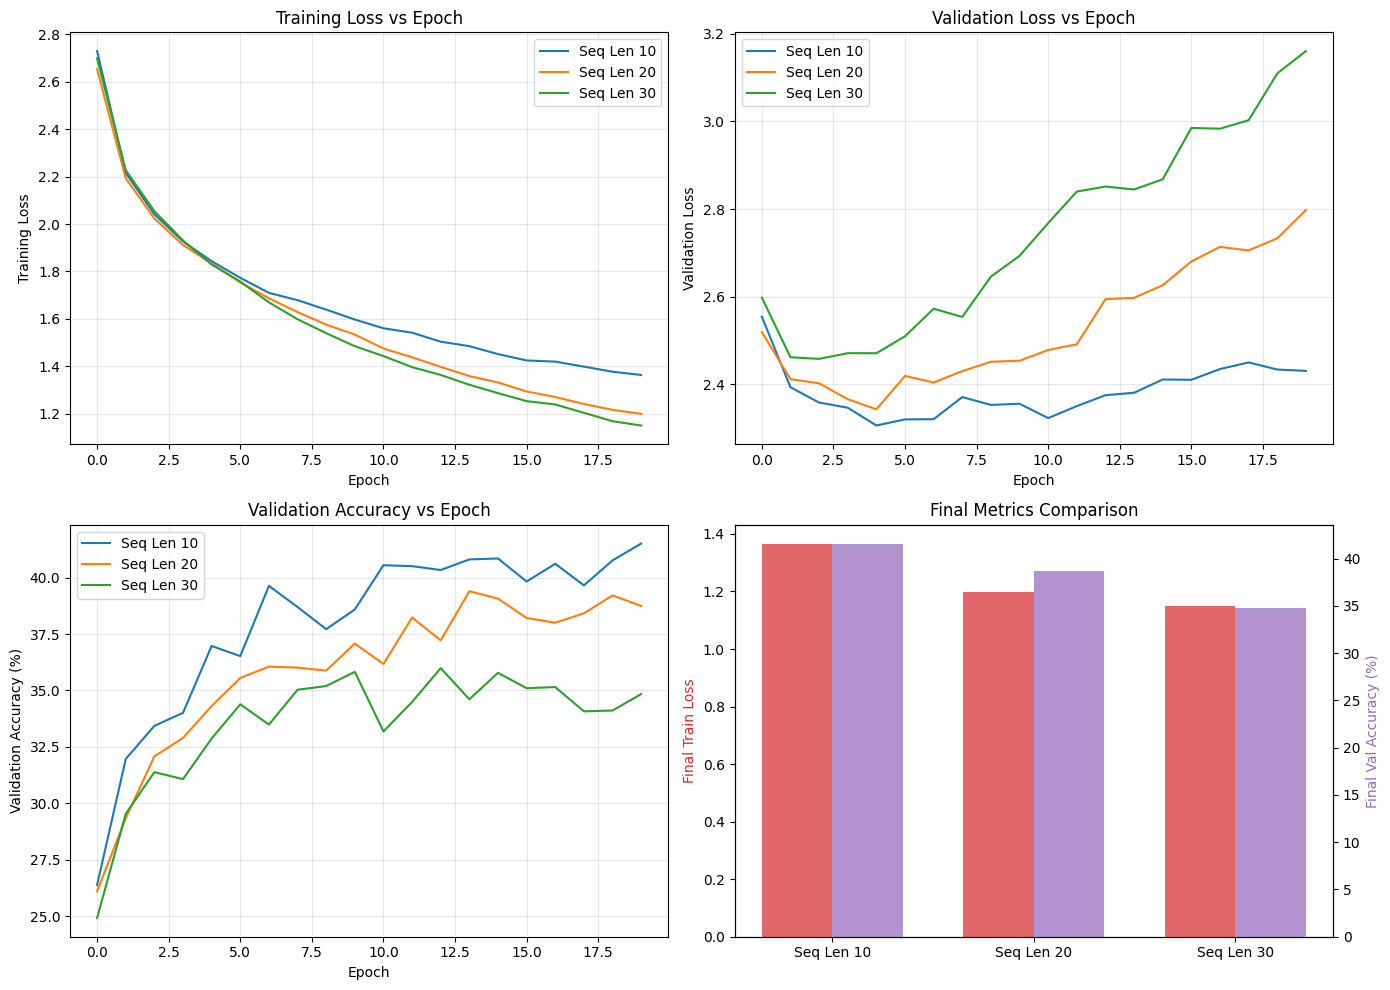

Seq Len   Final Train Loss    Final Val Loss    Final Val Acc %   Time (s)  
10        1.3634              2.4309            41.51             4.77      
20        1.1995              2.7977            38.75             4.40      
30        1.1503              3.1602            34.84             5.07      


In [15]:

# plot comparison across sequence Lengths (10, 20, 30)

# row 1: Training loss and Validation loss side by side
# row 2: Validation accuracy
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# collect all histories and labels for easy looping
histories = [history_seq10, history_seq20, history_seq30]
labels = ['Seq Len 10', 'Seq Len 20', 'Seq Len 30']
colors = ['tab:blue', 'tab:orange', 'tab:green']

# subplot 1: Training loss over epochs
ax = axes[0, 0]
for hist, label, color in zip(histories, labels, colors):
    ax.plot(hist['train_loss'], label=label, color=color)
ax.set_title('Training Loss vs Epoch')
ax.set_xlabel('Epoch')
ax.set_ylabel('Training Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# validation loss over epochs
ax = axes[0, 1]
for hist, label, color in zip(histories, labels, colors):
    ax.plot(hist['val_loss'], label=label, color=color)
ax.set_title('Validation Loss vs Epoch')
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# validation accuracy over epochs
ax = axes[1, 0]
for hist, label, color in zip(histories, labels, colors):
    ax.plot(hist['val_acc'], label=label, color=color)
ax.set_title('Validation Accuracy vs Epoch')
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Accuracy (%)')
ax.legend()
ax.grid(True, alpha=0.3)

# bar chart comparing final metrics across sequence lengths ---
ax = axes[1, 1]
final_train_loss = [hist['train_loss'][-1] for hist in histories]
final_val_acc = [hist['val_acc'][-1] for hist in histories]

x_pos = np.arange(len(labels))
width = 0.35

# plot final train loss on primary y-axis
bars1 = ax.bar(x_pos - width/2, final_train_loss, width, label='Final Train Loss', color='tab:red', alpha=0.7)
ax.set_ylabel('Final Train Loss', color='tab:red')
ax.set_xticks(x_pos)
ax.set_xticklabels(labels)

# creates a second y-axis sharing the same x-axis.
ax2 = ax.twinx()

# plot final val accuracy on secondary y-axis (different scale)
bars2 = ax2.bar(x_pos + width/2, final_val_acc, width, label='Final Val Acc (%)', color='tab:purple', alpha=0.7)
ax2.set_ylabel('Final Val Accuracy (%)', color='tab:purple')

ax.set_title('Final Metrics Comparison')

plt.tight_layout()
plt.savefig('problem1_transformer_comparison.png', dpi=150)
plt.show()

print(f"{'Seq Len':<10}{'Final Train Loss':<20}{'Final Val Loss':<18}{'Final Val Acc %':<18}{'Time (s)':<10}")
for hist, label in zip(histories, [10, 20, 30]):
    print(f"{label:<10}{hist['train_loss'][-1]:<20.4f}{hist['val_loss'][-1]:<18.4f}{hist['val_acc'][-1]:<18.2f}{hist['total_time']:<10.2f}")

In [16]:
# model size and computational complexity analysis


# since architecture is identical across seq_len 10/20/30, parameter count doesn't change (confirmed in Cells 7-9: all showed 105,773 params)
# this mirrors HW2's finding that RNN/LSTM/GRU parameter counts also stay fixed

TRANSFORMER_PARAMS = 105_773

print("=" * 60)
print("MODEL SIZE COMPARISON")
print("=" * 60)
print(f"{'Model':<15}{'Parameters':<15}{'Relative Size':<15}")
print(f"{'RNN (HW2)':<15}{'66,541':<15}{'1.0x':<15}")
print(f"{'GRU (HW2)':<15}{'182,253':<15}{'2.7x':<15}")
print(f"{'LSTM (HW2)':<15}{'240,109':<15}{'3.6x':<15}")
print(f"{'Transformer':<15}{TRANSFORMER_PARAMS:<15,}{TRANSFORMER_PARAMS/66541:.1f}x")

# computational complexity breakdown ---

print("\n" + "=" * 60)
print("COMPUTATIONAL COMPLEXITY (per forward pass)")
print("=" * 60)
print("""
RNN/LSTM/GRU (HW2):
  - Process sequence SEQUENTIALLY, one character at a time.
  - Complexity per sequence: O(seq_len * hidden_size^2)
  - Because each step depends on the previous hidden state, these steps
    CANNOT be parallelized across the sequence dimension — they must run
    one after another. This is why HW2's RNN/LSTM/GRU show training time
    scaling more noticeably with sequence length in some cases.

Transformer (this notebook):
  - Uses self-attention, which computes relationships between ALL pairs
    of positions in the sequence simultaneously.
  - Complexity per sequence: O(seq_len^2 * embed_size)
  - The seq_len^2 term means transformers scale WORSE than RNNs as
    sequence length grows very large, BUT because attention is fully
    parallelizable across the sequence dimension (no step-by-step
    dependency), transformers are typically much FASTER in wall-clock
    time on GPUs for short-to-moderate sequences like ours (10-30 chars).
  - This explains why our transformer trained in ~4 seconds across all
    three sequence lengths, comparable to or faster than HW2's RNN/LSTM/GRU
    (which ranged 1.9s-5.0s), despite the transformer having more parameters
    at 105,773 vs the smaller RNN's 66,541.
""")

# parameter breakdown by component, for a clearer picture of where params go
print("=" * 60)
print("TRANSFORMER PARAMETER BREAKDOWN")
print("=" * 60)
for name, param in model_seq10.named_parameters():
    if param.requires_grad:
        print(f"{name:<40}{param.numel():>10,}")

MODEL SIZE COMPARISON
Model          Parameters     Relative Size  
RNN (HW2)      66,541         1.0x           
GRU (HW2)      182,253        2.7x           
LSTM (HW2)     240,109        3.6x           
Transformer    105,773        1.6x

COMPUTATIONAL COMPLEXITY (per forward pass)

RNN/LSTM/GRU (HW2):
  - Process sequence SEQUENTIALLY, one character at a time.
  - Complexity per sequence: O(seq_len * hidden_size^2)
  - Because each step depends on the previous hidden state, these steps
    CANNOT be parallelized across the sequence dimension — they must run
    one after another. This is why HW2's RNN/LSTM/GRU show training time
    scaling more noticeably with sequence length in some cases.

Transformer (this notebook):
  - Uses self-attention, which computes relationships between ALL pairs
    of positions in the sequence simultaneously.
  - Complexity per sequence: O(seq_len^2 * embed_size)
  - The seq_len^2 term means transformers scale WORSE than RNNs as
    sequence length gr

In [17]:
# Problem 2

In [18]:

# Tiny Shakespeare Data Loader (provided by course, adapted into a function)


import requests

# Download the dataset (exactly as provided)
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
response = requests.get(url)
shakespeare_text = response.text  # full raw text

print(f"Total characters: {len(shakespeare_text)}")

# character vocabulary
# NOTE: prefixed with "shakespeare_" to avoid overwriting Problem 1's
# `chars`, `char_to_idx`, etc., which used a DIFFERENT 45-character vocab.
shakespeare_chars = sorted(list(set(shakespeare_text)))
shakespeare_char_to_int = {ch: i for i, ch in enumerate(shakespeare_chars)}
shakespeare_int_to_char = {i: ch for i, ch in enumerate(shakespeare_chars)}
shakespeare_vocab_size = len(shakespeare_chars)

print(f"Vocab size: {shakespeare_vocab_size}")
# NOTE: Should match HW2's reported 65 unique characters.

# encode the entire text into integers once (reused across all seq lengths)
shakespeare_encoded = [shakespeare_char_to_int[ch] for ch in shakespeare_text]


def make_shakespeare_dataset(sequence_length):
    """
    Builds (sequence, single_target) pairs using the provided course logic:
    for each position i, input = encoded_text[i : i+sequence_length]
    target = encoded_text[i+sequence_length]  <- SINGLE next character, not a sequence.

    Wrapped as a function so we can regenerate this for seq_len 20, 30, and 50
    without duplicating code (Problem 2 requires multiple sequence lengths).
    """
    sequences = []
    targets = []
    for i in range(0, len(shakespeare_encoded) - sequence_length):
        seq = shakespeare_encoded[i:i + sequence_length]
        target = shakespeare_encoded[i + sequence_length]
        sequences.append(seq)
        targets.append(target)

    sequences = torch.tensor(sequences, dtype=torch.long)
    targets = torch.tensor(targets, dtype=torch.long)
    return sequences, targets


class ShakespeareCharDataset(Dataset):
    """Dataset class exactly as provided by the course."""
    def __init__(self, sequences, targets):
        self.sequences = sequences
        self.targets = targets

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, index):
        return self.sequences[index], self.targets[index]


def make_shakespeare_dataloaders(sequence_length, batch_size=128):
    """
    Builds train/test DataLoaders for a given sequence length, following the
    provided course code: 80/20 random_split, shuffle=True for train only.
    """
    sequences, targets = make_shakespeare_dataset(sequence_length)
    dataset = ShakespeareCharDataset(sequences, targets)

    train_size = int(len(dataset) * 0.8)
    test_size = len(dataset) - train_size
    train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

    train_loader = DataLoader(train_dataset, shuffle=True, batch_size=batch_size)
    test_loader = DataLoader(test_dataset, shuffle=False, batch_size=batch_size)

    return train_loader, test_loader


# quick sanity check with seq_len=20 (matches provided code's default)
sh_train_loader_20, sh_val_loader_20 = make_shakespeare_dataloaders(sequence_length=20, batch_size=128)
xb, yb = next(iter(sh_train_loader_20))
print(f"\nSample input batch shape:  {xb.shape}")   # Expect: [128, 20]
print(f"Sample target batch shape: {yb.shape}")     # Expect: [128]

Total characters: 1115394
Vocab size: 65

Sample input batch shape:  torch.Size([128, 20])
Sample target batch shape: torch.Size([128])


In [19]:
# tansformer model for many-to-one Character Prediction

class ShakespeareCharTransformer(nn.Module):
    """
    Transformer for Tiny Shakespeare next-character prediction, adapted for
    the PROVIDED data loader's many-to-one format: given a sequence of
    `sequence_length` characters, predict only the SINGLE next character
    (not a full shifted sequence, unlike Problem 1's model).

    Architecture is otherwise the same as Problem 1's CharTransformer:
      1. Token embedding + positional encoding
      2. Stack of transformer encoder blocks (self-attention + feedforward)
      3. Output projection — but applied ONLY to the LAST position's hidden
         state, since we only need one prediction per input sequence.

    num_blocks and num_heads are exposed as constructor args so we can sweep
    over the 8 required configurations (1/2/4 blocks x 2/4 heads) later
    without rewriting this class each time.
    """

    def __init__(self, vocab_size, embed_size=64, num_heads=2, num_blocks=2,
                 ff_hidden_size=256, dropout=0.1, max_len=5000):
        super().__init__()
        self.embed_size = embed_size

        # token embedding: char indices to dense vectors
        self.token_embedding = nn.Embedding(vocab_size, embed_size)

        # positional encoding (reused from Cell 4 - works for any vocab)
        self.pos_encoding = PositionalEncoding(embed_size, max_len=max_len)
        self.dropout = nn.Dropout(dropout)

        # stack of transformer encoder blocks
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_size,
            nhead=num_heads,
            dim_feedforward=ff_hidden_size,
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_blocks)

        # output projection: embed_size to vocab_size
        # Applied only to the last position's output (see forward())
        self.output_proj = nn.Linear(embed_size, vocab_size)

    def _generate_causal_mask(self, seq_len, device):
        """Same causal mask logic as Problem 1 — prevents attending to future positions."""
        mask = torch.triu(torch.ones(seq_len, seq_len, device=device), diagonal=1)
        mask = mask.masked_fill(mask == 1, float('-inf'))
        return mask

    def forward(self, x):
        # x shape: [batch_size, seq_len]
        batch_size, seq_len = x.shape

        # embed + scale + positional encoding (same as Problem 1)
        x = self.token_embedding(x) * math.sqrt(self.embed_size)
        x = self.pos_encoding(x)
        x = self.dropout(x)

        # causal mask so the last position can only see itself and earlier
        # technically for many-to-one prediction, only the last position's mask
        causal_mask = self._generate_causal_mask(seq_len, x.device)

        # pass through transformer blocks
        x = self.transformer_encoder(x, mask=causal_mask)  # [batch, seq_len, embed_size]

        # KEY DIFFERENCE from Problem 1: only take the LAST position's output
        last_hidden = x[:, -1, :]  # [batch, embed_size]

        # project to vocab-size logits
        logits = self.output_proj(last_hidden)  # [batch, vocab_size]

        return logits


# sanity check
test_sh_model = ShakespeareCharTransformer(
    vocab_size=shakespeare_vocab_size, embed_size=64, num_heads=2, num_blocks=2
).to(device)

xb_test, yb_test = next(iter(sh_train_loader_20))
xb_test, yb_test = xb_test.to(device), yb_test.to(device)

logits = test_sh_model(xb_test)
print(f"Input shape:  {xb_test.shape}")   # [128, 20]
print(f"Target shape: {yb_test.shape}")   # [128]
print(f"Output shape: {logits.shape}")    # Expect: [128, 65]

num_params = sum(p.numel() for p in test_sh_model.parameters() if p.requires_grad)
print(f"Total trainable parameters (2 blocks, 2 heads): {num_params:,}")

Input shape:  torch.Size([128, 20])
Target shape: torch.Size([128])
Output shape: torch.Size([128, 65])
Total trainable parameters (2 blocks, 2 heads): 108,353


In [20]:
#training loop for many-to-one character prediction


def train_shakespeare_model(model, train_loader, val_loader, num_epochs=20,
                             learning_rate=0.0005, device=device, verbose_every=5):
    """
    Training loop adapted for the many-to-one Shakespeare setup.

    Key differences from Problem 1's train_model (Cell 6):
      - Loss is computed directly on [batch, vocab_size] vs [batch] targets
        (no reshape needed, since there's only one prediction per example).
      - We also compute perplexity = e^(validation loss), matching HW2's
        reporting convention (perplexity measures how "confused" the model
        is when predicting the next character — lower is better).

    NOTE: default learning_rate=0.0005, not 0.003 — matching your HW2 report,
    which found that lr=0.003 caused GRU to diverge on this larger dataset.
    We use the same lower learning rate here to keep training stable on the
    full Tiny Shakespeare dataset (1.1M characters).
    """

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    history = {
        'train_loss': [],
        'val_loss': [],
        'val_acc': [],
        'val_perplexity': []
    }

    start_time = time.time()

    for epoch in range(num_epochs):
        # training phase

        model.train()
        total_train_loss = 0.0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()

            logits = model(xb)  # [batch, vocab_size]

            # no reshape needed here (unlike Problem 1) since logits is
            loss = criterion(logits, yb)

            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        history['train_loss'].append(avg_train_loss)

        # validation phase

        model.eval()
        total_val_loss = 0.0
        correct_preds = 0
        total_preds = 0

        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)

                logits = model(xb)
                loss = criterion(logits, yb)
                total_val_loss += loss.item()

                preds = logits.argmax(dim=-1)  # [batch] — predicted next char per example
                correct_preds += (preds == yb).sum().item()
                total_preds += yb.numel()

        avg_val_loss = total_val_loss / len(val_loader)
        val_accuracy = 100.0 * correct_preds / total_preds
        val_perplexity = math.exp(avg_val_loss)  # matches HW2's e^(val_loss) convention

        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(val_accuracy)
        history['val_perplexity'].append(val_perplexity)

        if (epoch + 1) % verbose_every == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{num_epochs} | "
                  f"Train Loss: {avg_train_loss:.4f} | "
                  f"Val Loss: {avg_val_loss:.4f} | "
                  f"Val Acc: {val_accuracy:.2f}% | "
                  f"Perplexity: {val_perplexity:.2f}")

    total_time = time.time() - start_time
    history['total_time'] = total_time

    print(f"\nTraining complete in {total_time:.2f}s")
    print(f"Final Train Loss: {history['train_loss'][-1]:.4f} | "
          f"Final Val Acc: {history['val_acc'][-1]:.2f}% | "
          f"Final Perplexity: {history['val_perplexity'][-1]:.2f}")

    return history

In [21]:
# reusable function for hyperparameter sweep (Blocks x Heads)

def run_shakespeare_config(num_blocks, num_heads, sequence_length=20, embed_size=64,
                             ff_hidden_size=256, num_epochs=20, learning_rate=0.0005,
                             batch_size=128, device=device, verbose_every=10):
    """
    Builds, trains, and evaluates a ShakespeareCharTransformer for a given
    (num_blocks, num_heads) configuration. Used to run the required 8-combination
    sweep (1/2/4 blocks x 2/4 heads) for Problem 2 without repeating code
    for each of the 8 runs.

    Returns a dict containing the config, trained model, training history,
    and parameter count — everything needed for the final comparison table/plots.
    """

    print(f"\n{'='*60}")
    print(f"Config: {num_blocks} blocks, {num_heads} heads, seq_len={sequence_length}")
    print(f"{'='*60}")

    # build data loaders for this sequence length
    train_loader, val_loader = make_shakespeare_dataloaders(
        sequence_length=sequence_length, batch_size=batch_size
    )

    # instantiate model with the specified config
    model = ShakespeareCharTransformer(
        vocab_size=shakespeare_vocab_size,
        embed_size=embed_size,
        num_heads=num_heads,
        num_blocks=num_blocks,
        ff_hidden_size=ff_hidden_size,
        dropout=0.1
    ).to(device)

    num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Parameters: {num_params:,}")

    # train using the existing training loop from Cell 15
    history = train_shakespeare_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        num_epochs=num_epochs,
        learning_rate=learning_rate,
        device=device,
        verbose_every=verbose_every
    )

    # measure single-batch inference time (ms)
    model.eval()
    xb_sample, _ = next(iter(val_loader))
    xb_sample = xb_sample.to(device)
    with torch.no_grad():
        torch.cuda.synchronize() if torch.cuda.is_available() else None
        infer_start = time.time()
        _ = model(xb_sample)
        torch.cuda.synchronize() if torch.cuda.is_available() else None
        infer_time_ms = (time.time() - infer_start) * 1000

    return {
        'num_blocks': num_blocks,
        'num_heads': num_heads,
        'sequence_length': sequence_length,
        'num_params': num_params,
        'history': history,
        'inference_ms': infer_time_ms,
        'model': model
    }

In [22]:
print(run_shakespeare_config)

<function run_shakespeare_config at 0x78086eff77e0>


In [23]:

# train baseline transformer (2 blocks, 2 heads) on seq Length 20


# build data loaders for seq_len=20 (already have sh_train_loader_20, sh_val_loader_20
sh_train_loader_20, sh_val_loader_20 = make_shakespeare_dataloaders(sequence_length=20, batch_size=128)

# baseline model: 2 transformer blocks, 2 attention heads
# required starting configuration for Problem 2.
model_sh_base_20 = ShakespeareCharTransformer(
    vocab_size=shakespeare_vocab_size,
    embed_size=64,
    num_heads=2,
    num_blocks=2,
    ff_hidden_size=256,
    dropout=0.1
).to(device)

num_params_base_20 = sum(p.numel() for p in model_sh_base_20.parameters() if p.requires_grad)
print(f"Model parameters (2 blocks, 2 heads, seq_len=20): {num_params_base_20:,}")

# train
# 20 epochs matches HW2
print(f"\nTraining baseline transformer (2 blocks, 2 heads) on sequence length 20...\n")
history_sh_base_20 = train_shakespeare_model(
    model=model_sh_base_20,
    train_loader=sh_train_loader_20,
    val_loader=sh_val_loader_20,
    num_epochs=20,
    learning_rate=0.0005,
    device=device
)

Model parameters (2 blocks, 2 heads, seq_len=20): 108,353

Training baseline transformer (2 blocks, 2 heads) on sequence length 20...

Epoch 1/20 | Train Loss: 2.4471 | Val Loss: 2.2153 | Val Acc: 34.87% | Perplexity: 9.16
Epoch 5/20 | Train Loss: 2.0243 | Val Loss: 1.8690 | Val Acc: 44.11% | Perplexity: 6.48
Epoch 10/20 | Train Loss: 1.8940 | Val Loss: 1.7473 | Val Acc: 47.32% | Perplexity: 5.74
Epoch 15/20 | Train Loss: 1.8371 | Val Loss: 1.6937 | Val Acc: 48.84% | Perplexity: 5.44
Epoch 20/20 | Train Loss: 1.8022 | Val Loss: 1.6580 | Val Acc: 49.80% | Perplexity: 5.25

Training complete in 1047.17s
Final Train Loss: 1.8022 | Final Val Acc: 49.80% | Final Perplexity: 5.25


In [24]:
# train baseline transformer (2 blocks, 2 heads) on seq Length 30


# build data loaders for seq_len=30
sh_train_loader_30, sh_val_loader_30 = make_shakespeare_dataloaders(sequence_length=30, batch_size=128)

# baseline model (same config as seq_len=20, for fair comparison) ---
model_sh_base_30 = ShakespeareCharTransformer(
    vocab_size=shakespeare_vocab_size,
    embed_size=64,
    num_heads=2,
    num_blocks=2,
    ff_hidden_size=256,
    dropout=0.1
).to(device)

num_params_base_30 = sum(p.numel() for p in model_sh_base_30.parameters() if p.requires_grad)
print(f"Model parameters (2 blocks, 2 heads, seq_len=30): {num_params_base_30:,}")

# train
print(f"\nTraining baseline transformer (2 blocks, 2 heads) on sequence length 30...\n")
history_sh_base_30 = train_shakespeare_model(
    model=model_sh_base_30,
    train_loader=sh_train_loader_30,
    val_loader=sh_val_loader_30,
    num_epochs=20,
    learning_rate=0.0005,
    device=device
)

Model parameters (2 blocks, 2 heads, seq_len=30): 108,353

Training baseline transformer (2 blocks, 2 heads) on sequence length 30...

Epoch 1/20 | Train Loss: 2.4753 | Val Loss: 2.3521 | Val Acc: 30.55% | Perplexity: 10.51
Epoch 5/20 | Train Loss: 2.0636 | Val Loss: 1.9027 | Val Acc: 43.33% | Perplexity: 6.70
Epoch 10/20 | Train Loss: 1.9124 | Val Loss: 1.7661 | Val Acc: 47.20% | Perplexity: 5.85
Epoch 15/20 | Train Loss: 1.8490 | Val Loss: 1.7077 | Val Acc: 48.56% | Perplexity: 5.52
Epoch 20/20 | Train Loss: 1.8125 | Val Loss: 1.6723 | Val Acc: 49.59% | Perplexity: 5.32

Training complete in 1074.07s
Final Train Loss: 1.8125 | Final Val Acc: 49.59% | Final Perplexity: 5.32


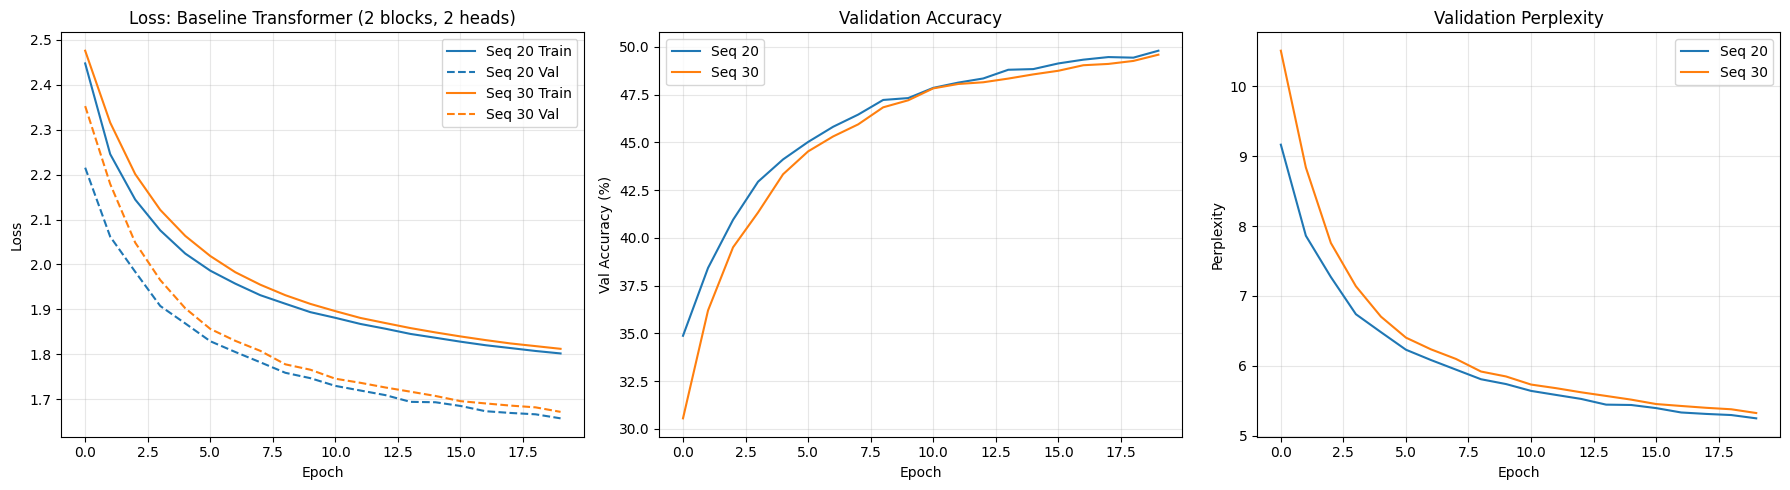

Model          SeqLen    Train Loss    Val Loss    Val Acc%    Perplexity  Time(s)     Params      
LSTM (HW2)     20        1.3962        1.4335      56.11       4.19        706.63      243,969     
GRU (HW2)      20        1.2662        1.3661      58.22       3.92        603.74      186,113     
Transformer    20        1.8022        1.6580      49.80       5.25        1047.17     108,353     

LSTM (HW2)     30        1.3737        1.4085      56.73       4.09        852.49      243,969     
GRU (HW2)      30        1.2571        1.3547      58.65       3.88        672.54      186,113     
Transformer    30        1.8125        1.6723      49.59       5.32        1074.07     108,353     


In [25]:

# plot loss and accuracy curves for both sequence lengths
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# training + validation Loss
ax = axes[0]
ax.plot(history_sh_base_20['train_loss'], label='Seq 20 Train', color='tab:blue')
ax.plot(history_sh_base_20['val_loss'], label='Seq 20 Val', color='tab:blue', linestyle='--')
ax.plot(history_sh_base_30['train_loss'], label='Seq 30 Train', color='tab:orange')
ax.plot(history_sh_base_30['val_loss'], label='Seq 30 Val', color='tab:orange', linestyle='--')
ax.set_title('Loss: Baseline Transformer (2 blocks, 2 heads)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# validation accuracy
ax = axes[1]
ax.plot(history_sh_base_20['val_acc'], label='Seq 20', color='tab:blue')
ax.plot(history_sh_base_30['val_acc'], label='Seq 30', color='tab:orange')
ax.set_title('Validation Accuracy')
ax.set_xlabel('Epoch')
ax.set_ylabel('Val Accuracy (%)')
ax.legend()
ax.grid(True, alpha=0.3)

# perplexity
ax = axes[2]
ax.plot(history_sh_base_20['val_perplexity'], label='Seq 20', color='tab:blue')
ax.plot(history_sh_base_30['val_perplexity'], label='Seq 30', color='tab:orange')
ax.set_title('Validation Perplexity')
ax.set_xlabel('Epoch')
ax.set_ylabel('Perplexity')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('problem2_baseline_seq20_vs_seq30.png', dpi=150)
plt.show()

# --- Print comparison table: Transformer (seq 20, 30) vs HW2 GRU/LSTM ---
print(f"{'Model':<15}{'SeqLen':<10}{'Train Loss':<14}{'Val Loss':<12}{'Val Acc%':<12}{'Perplexity':<12}{'Time(s)':<12}{'Params':<12}")
print(f"{'LSTM (HW2)':<15}{'20':<10}{'1.3962':<14}{'1.4335':<12}{'56.11':<12}{'4.19':<12}{'706.63':<12}{'243,969':<12}")
print(f"{'GRU (HW2)':<15}{'20':<10}{'1.2662':<14}{'1.3661':<12}{'58.22':<12}{'3.92':<12}{'603.74':<12}{'186,113':<12}")
print(f"{'Transformer':<15}{'20':<10}{history_sh_base_20['train_loss'][-1]:<14.4f}{history_sh_base_20['val_loss'][-1]:<12.4f}{history_sh_base_20['val_acc'][-1]:<12.2f}{history_sh_base_20['val_perplexity'][-1]:<12.2f}{history_sh_base_20['total_time']:<12.2f}{num_params_base_20:<12,}")
print()
print(f"{'LSTM (HW2)':<15}{'30':<10}{'1.3737':<14}{'1.4085':<12}{'56.73':<12}{'4.09':<12}{'852.49':<12}{'243,969':<12}")
print(f"{'GRU (HW2)':<15}{'30':<10}{'1.2571':<14}{'1.3547':<12}{'58.65':<12}{'3.88':<12}{'672.54':<12}{'186,113':<12}")
print(f"{'Transformer':<15}{'30':<10}{history_sh_base_30['train_loss'][-1]:<14.4f}{history_sh_base_30['val_loss'][-1]:<12.4f}{history_sh_base_30['val_acc'][-1]:<12.2f}{history_sh_base_30['val_perplexity'][-1]:<12.2f}{history_sh_base_30['total_time']:<12.2f}{num_params_base_30:<12,}")

In [26]:
# sweep configs — 1 Block (2 heads, 4 heads)


# store all sweep results in a list
sweep_results = []

# config 1: 1 transformer block, 2 attention heads
result_1b_2h = run_shakespeare_config(
    num_blocks=1,
    num_heads=2,
    sequence_length=20,
    num_epochs=20,
    learning_rate=0.0005
)
sweep_results.append(result_1b_2h)

# config 2: 1 transformer block, 4 attention heads
result_1b_4h = run_shakespeare_config(
    num_blocks=1,
    num_heads=4,
    sequence_length=20,
    num_epochs=20,
    learning_rate=0.0005
)
sweep_results.append(result_1b_4h)

print("\n" + "="*60)
print("Cell 20 complete: 2/8 configs done")
print("="*60)


Config: 1 blocks, 2 heads, seq_len=20
Parameters: 58,369
Epoch 1/20 | Train Loss: 2.5387 | Val Loss: 2.4391 | Val Acc: 27.92% | Perplexity: 11.46
Epoch 10/20 | Train Loss: 2.3920 | Val Loss: 2.3495 | Val Acc: 29.89% | Perplexity: 10.48
Epoch 20/20 | Train Loss: 2.3072 | Val Loss: 2.2164 | Val Acc: 34.31% | Perplexity: 9.17

Training complete in 724.19s
Final Train Loss: 2.3072 | Final Val Acc: 34.31% | Final Perplexity: 9.17

Config: 1 blocks, 4 heads, seq_len=20
Parameters: 58,369
Epoch 1/20 | Train Loss: 2.5292 | Val Loss: 2.4225 | Val Acc: 28.37% | Perplexity: 11.27
Epoch 10/20 | Train Loss: 2.3682 | Val Loss: 2.3204 | Val Acc: 31.07% | Perplexity: 10.18
Epoch 20/20 | Train Loss: 2.2544 | Val Loss: 2.1367 | Val Acc: 36.43% | Perplexity: 8.47

Training complete in 725.31s
Final Train Loss: 2.2544 | Final Val Acc: 36.43% | Final Perplexity: 8.47

Cell 20 complete: 2/8 configs done


In [27]:
# sweep config — 2 Blocks, 4 Heads


# 2 transformer blocks, 4 attention heads
# (2 blocks, 2 heads) was already trained in Cell 16 as the baseline
result_2b_2h_baseline = {
    'num_blocks': 2,
    'num_heads': 2,
    'sequence_length': 20,
    'num_params': num_params_base_20,
    'history': history_sh_base_20,
    'inference_ms': None,  # not measured for the baseline run, only for sweep configs
    'model': model_sh_base_20
}
sweep_results.append(result_2b_2h_baseline)

# now train the missing 2-block config: 2 blocks, 4 heads
result_2b_4h = run_shakespeare_config(
    num_blocks=2,
    num_heads=4,
    sequence_length=20,
    num_epochs=20,
    learning_rate=0.0005
)
sweep_results.append(result_2b_4h)

print("\n" + "="*60)
print(f"Cell 21 complete: {len(sweep_results)}/8 configs done")
print("="*60)


Config: 2 blocks, 4 heads, seq_len=20
Parameters: 108,353
Epoch 1/20 | Train Loss: 2.4343 | Val Loss: 2.2420 | Val Acc: 34.01% | Perplexity: 9.41
Epoch 10/20 | Train Loss: 1.8661 | Val Loss: 1.7302 | Val Acc: 47.89% | Perplexity: 5.64
Epoch 20/20 | Train Loss: 1.7808 | Val Loss: 1.6552 | Val Acc: 49.65% | Perplexity: 5.23

Training complete in 1032.35s
Final Train Loss: 1.7808 | Final Val Acc: 49.65% | Final Perplexity: 5.23

Cell 21 complete: 4/8 configs done


In [28]:
# sweep configs — 4 Blocks (2 heads, 4 heads)

# config: 4 transformer blocks, 2 attention heads
result_4b_2h = run_shakespeare_config(
    num_blocks=4,
    num_heads=2,
    sequence_length=20,
    num_epochs=20,
    learning_rate=0.0005
)
sweep_results.append(result_4b_2h)

# config: 4 transformer blocks, 4 attention heads
result_4b_4h = run_shakespeare_config(
    num_blocks=4,
    num_heads=4,
    sequence_length=20,
    num_epochs=20,
    learning_rate=0.0005
)
sweep_results.append(result_4b_4h)

print("\n" + "="*60)
print(f"Cell 22 complete: {len(sweep_results)}/8 configs done — full sweep finished!")
print("="*60)


Config: 4 blocks, 2 heads, seq_len=20
Parameters: 208,321
Epoch 1/20 | Train Loss: 2.2955 | Val Loss: 1.9868 | Val Acc: 41.20% | Perplexity: 7.29
Epoch 10/20 | Train Loss: 1.7133 | Val Loss: 1.5950 | Val Acc: 51.46% | Perplexity: 4.93
Epoch 20/20 | Train Loss: 1.6452 | Val Loss: 1.5356 | Val Acc: 53.13% | Perplexity: 4.64

Training complete in 1669.52s
Final Train Loss: 1.6452 | Final Val Acc: 53.13% | Final Perplexity: 4.64

Config: 4 blocks, 4 heads, seq_len=20
Parameters: 208,321
Epoch 1/20 | Train Loss: 2.2842 | Val Loss: 1.9715 | Val Acc: 41.33% | Perplexity: 7.18
Epoch 10/20 | Train Loss: 1.6898 | Val Loss: 1.5791 | Val Acc: 51.98% | Perplexity: 4.85
Epoch 20/20 | Train Loss: 1.6198 | Val Loss: 1.5171 | Val Acc: 53.46% | Perplexity: 4.56

Training complete in 1687.87s
Final Train Loss: 1.6198 | Final Val Acc: 53.46% | Final Perplexity: 4.56

Cell 22 complete: 6/8 configs done — full sweep finished!


Blocks  Heads   Params      Train Loss    Val Loss    Val Acc%    Perplexity  Time(s)     
------------------------------------------------------------------------------------------
1       2       58,369      2.3072        2.2164      34.31       9.17        724.19      
1       4       58,369      2.2544        2.1367      36.43       8.47        725.31      
2       2       108,353     1.8022        1.6580      49.80       5.25        1047.17     
2       4       108,353     1.7808        1.6552      49.65       5.23        1032.35     
4       2       208,321     1.6452        1.5356      53.13       4.64        1669.52     
4       4       208,321     1.6198        1.5171      53.46       4.56        1687.87     


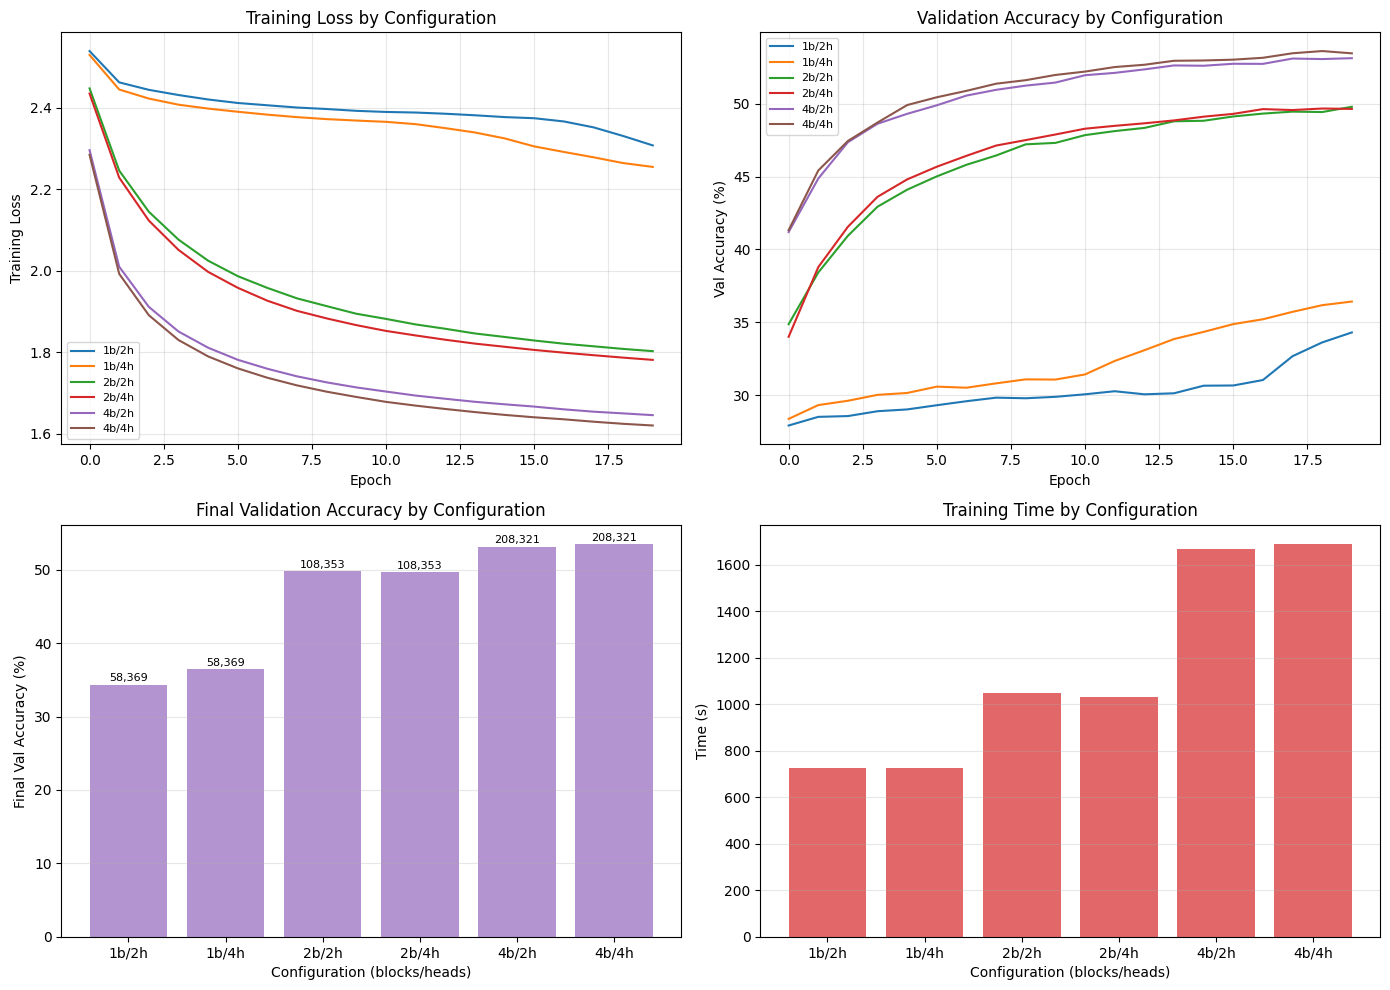


Best config by validation accuracy: 4 blocks, 4 heads — Val Acc: 53.46%


In [29]:
# comparison Table + Plots Across All Sweep Configs


# build a clean summary table from sweep_results
print(f"{'Blocks':<8}{'Heads':<8}{'Params':<12}{'Train Loss':<14}{'Val Loss':<12}{'Val Acc%':<12}{'Perplexity':<12}{'Time(s)':<12}")
print("-" * 90)
for r in sweep_results:
    h = r['history']
    print(f"{r['num_blocks']:<8}{r['num_heads']:<8}{r['num_params']:<12,}"
          f"{h['train_loss'][-1]:<14.4f}{h['val_loss'][-1]:<12.4f}"
          f"{h['val_acc'][-1]:<12.2f}{h['val_perplexity'][-1]:<12.2f}{h['total_time']:<12.2f}")

# sort a copy by (blocks, heads) for consistent plotting order
sorted_results = sorted(sweep_results, key=lambda r: (r['num_blocks'], r['num_heads']))

# build labels like for x-axis
config_labels = [f"{r['num_blocks']}b/{r['num_heads']}h" for r in sorted_results]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# training loss curves for all configs
ax = axes[0, 0]
for r, label in zip(sorted_results, config_labels):
    ax.plot(r['history']['train_loss'], label=label)
ax.set_title('Training Loss by Configuration')
ax.set_xlabel('Epoch')
ax.set_ylabel('Training Loss')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# validation accuracy curves for all configs
ax = axes[0, 1]
for r, label in zip(sorted_results, config_labels):
    ax.plot(r['history']['val_acc'], label=label)
ax.set_title('Validation Accuracy by Configuration')
ax.set_xlabel('Epoch')
ax.set_ylabel('Val Accuracy (%)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# final val accuracy vs parameter count
ax = axes[1, 0]
final_accs = [r['history']['val_acc'][-1] for r in sorted_results]
params_list = [r['num_params'] for r in sorted_results]
bars = ax.bar(config_labels, final_accs, color='tab:purple', alpha=0.7)
ax.set_title('Final Validation Accuracy by Configuration')
ax.set_xlabel('Configuration (blocks/heads)')
ax.set_ylabel('Final Val Accuracy (%)')
ax.grid(True, alpha=0.3, axis='y')
# Annotate each bar with its parameter count
for bar, params in zip(bars, params_list):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{params:,}', ha='center', fontsize=8, rotation=0)

# training time vs configuration
ax = axes[1, 1]
times = [r['history']['total_time'] for r in sorted_results]
ax.bar(config_labels, times, color='tab:red', alpha=0.7)
ax.set_title('Training Time by Configuration')
ax.set_xlabel('Configuration (blocks/heads)')
ax.set_ylabel('Time (s)')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('problem2_sweep_comparison.png', dpi=150)
plt.show()

# identify best config by validation accuracy, for use in Cell 24/25 (seq_len=50 run)
best_config = max(sweep_results, key=lambda r: r['history']['val_acc'][-1])
print(f"\nBest config by validation accuracy: {best_config['num_blocks']} blocks, "
      f"{best_config['num_heads']} heads — Val Acc: {best_config['history']['val_acc'][-1]:.2f}%")

In [30]:

# train best configuration at sequence Length 50

# use the best config identified in Cell 23: 4 blocks, 4 heads

print(f"Training best config (4 blocks, 4 heads) at sequence length 50...\n")

result_seq50 = run_shakespeare_config(
    num_blocks=4,
    num_heads=4,
    sequence_length=50,
    num_epochs=20,
    learning_rate=0.0005
)

print("\n" + "="*60)
print("Sequence Length 50 training complete")
print("="*60)
print(f"Blocks: {result_seq50['num_blocks']}, Heads: {result_seq50['num_heads']}")
print(f"Parameters: {result_seq50['num_params']:,}")
print(f"Final Train Loss: {result_seq50['history']['train_loss'][-1]:.4f}")
print(f"Final Val Loss: {result_seq50['history']['val_loss'][-1]:.4f}")
print(f"Final Val Acc: {result_seq50['history']['val_acc'][-1]:.2f}%")
print(f"Final Perplexity: {result_seq50['history']['val_perplexity'][-1]:.2f}")
print(f"Training Time: {result_seq50['history']['total_time']:.2f}s")

# compare against seq_len=20 result for the SAME config, to isolate
# the effect of sequence length alone
same_config_seq20 = next(r for r in sweep_results if r['num_blocks'] == 4 and r['num_heads'] == 4)

print("\n" + "="*60)
print("Comparison: Same Config (4 blocks, 4 heads) — Seq 20 vs Seq 50")
print("="*60)
print(f"{'SeqLen':<10}{'Val Acc%':<12}{'Perplexity':<12}{'Time(s)':<12}")
print(f"{'20':<10}{same_config_seq20['history']['val_acc'][-1]:<12.2f}"
      f"{same_config_seq20['history']['val_perplexity'][-1]:<12.2f}"
      f"{same_config_seq20['history']['total_time']:<12.2f}")
print(f"{'50':<10}{result_seq50['history']['val_acc'][-1]:<12.2f}"
      f"{result_seq50['history']['val_perplexity'][-1]:<12.2f}"
      f"{result_seq50['history']['total_time']:<12.2f}")

Training best config (4 blocks, 4 heads) at sequence length 50...


Config: 4 blocks, 4 heads, seq_len=50
Parameters: 208,321
Epoch 1/20 | Train Loss: 2.3903 | Val Loss: 2.0521 | Val Acc: 38.99% | Perplexity: 7.78
Epoch 10/20 | Train Loss: 1.6881 | Val Loss: 1.5678 | Val Acc: 52.31% | Perplexity: 4.80
Epoch 20/20 | Train Loss: 1.6141 | Val Loss: 1.5031 | Val Acc: 53.91% | Perplexity: 4.50

Training complete in 2007.89s
Final Train Loss: 1.6141 | Final Val Acc: 53.91% | Final Perplexity: 4.50

Sequence Length 50 training complete
Blocks: 4, Heads: 4
Parameters: 208,321
Final Train Loss: 1.6141
Final Val Loss: 1.5031
Final Val Acc: 53.91%
Final Perplexity: 4.50
Training Time: 2007.89s

Comparison: Same Config (4 blocks, 4 heads) — Seq 20 vs Seq 50
SeqLen    Val Acc%    Perplexity  Time(s)     
20        53.46       4.56        1687.87     
50        53.91       4.50        2007.89     


In [31]:
from google.colab import files
uploaded = files.upload()  #vast_english_french.txt

Saving vast_english_french.txt to vast_english_french.txt


In [32]:

#  25: English-French Dataset (matches HW3 exactly)

from collections import Counter

# after using files.upload(), matching how HW3's Colab notebook did it).
DATA_PATH = "/content/vast_english_french.txt"# same constants as HW3, for exact reproducibility
MAX_LEN = 50
MIN_FREQ = 2
TRANSLATION_BATCH_SIZE = 64

# special tokens (same fixed indices as HW3)
PAD, SOS, EOS, UNK = "<pad>", "<sos>", "<eos>", "<unk>"


class Vocab:
    """Vocabulary class — identical logic to HW3's Vocab class."""
    def __init__(self):
        self.word2idx = {PAD: 0, SOS: 1, EOS: 2, UNK: 3}
        self.idx2word = {0: PAD, 1: SOS, 2: EOS, 3: UNK}

    def build(self, sentences, min_freq=MIN_FREQ):
        counts = Counter(w for s in sentences for w in s)
        for word, freq in counts.items():
            if freq >= min_freq and word not in self.word2idx:
                idx = len(self.word2idx)
                self.word2idx[word] = idx
                self.idx2word[idx] = word

    def encode(self, tokens):
        return [self.word2idx.get(t, self.word2idx[UNK]) for t in tokens]

    def __len__(self):
        return len(self.word2idx)


def load_translation_data(path, max_len=MAX_LEN):
    """Loads and tokenizes the tab-separated English-French file — same as HW3."""
    eng_sentences, fra_sentences = [], []
    with open(path, encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split("\t")
            if len(parts) < 2:
                continue
            eng = parts[0].lower().split()
            fra = parts[1].lower().split()
            if len(eng) <= max_len and len(fra) <= max_len:
                eng_sentences.append(eng)
                fra_sentences.append(fra)
    return eng_sentences, fra_sentences


# load the full dataset
eng_all, fra_all = load_translation_data(DATA_PATH)
print(f"Total sentence pairs loaded: {len(eng_all)}")
# NOTE: Should match HW3's 555 sentence pairs.

# 80/20 split
split_idx = int(0.8 * len(eng_all))
eng_train, eng_val = eng_all[:split_idx], eng_all[split_idx:]
fra_train, fra_val = fra_all[:split_idx], fra_all[split_idx:]
print(f"Train pairs: {len(eng_train)}  |  Val pairs: {len(eng_val)}")

# build vocab on training data only (matches HW3)
src_vocab = Vocab()  # English vocabulary (source, for Problem 3)
tgt_vocab = Vocab()  # French vocabulary (target, for Problem 3)
src_vocab.build(eng_train)
tgt_vocab.build(fra_train)
print(f"English vocab size: {len(src_vocab)}  |  French vocab size: {len(tgt_vocab)}")


Total sentence pairs loaded: 555
Train pairs: 444  |  Val pairs: 111
English vocab size: 353  |  French vocab size: 366


In [33]:

#26

class TranslationDataset(Dataset):
    """
    Wraps English-French sentence pairs for PyTorch's DataLoader.
    Identical logic to HW3's TranslationDataset.

    Source (English) gets an <eos> token appended.
    Target (French) gets <sos> prepended and <eos> appended — this is
    standard for seq2seq: the decoder starts generation from <sos> and
    learns to predict <eos> to signal "done".
    """
    def __init__(self, src_sents, tgt_sents, src_vocab, tgt_vocab):
        self.pairs = list(zip(src_sents, tgt_sents))
        self.sv = src_vocab
        self.tv = tgt_vocab

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        src, tgt = self.pairs[idx]
        src_ids = self.sv.encode(src) + [self.sv.word2idx[EOS]]
        tgt_ids = [self.tv.word2idx[SOS]] + self.tv.encode(tgt) + [self.tv.word2idx[EOS]]
        return torch.tensor(src_ids), torch.tensor(tgt_ids)


def make_translation_collate_fn(src_vocab, tgt_vocab):
    """
    Returns a collate function that pads variable-length sentences in a
    batch to the same length, using the given vocabularies' PAD index.

    Wrapped in a factory function (rather than a fixed collate_fn like HW3's)
    so we can reuse this for Problem 4's reversed direction later, where
    src_vocab/tgt_vocab will be French/English instead of English/French.
    """
    def collate_fn(batch):
        src_batch, tgt_batch = zip(*batch)
        src_pad = nn.utils.rnn.pad_sequence(
            src_batch, batch_first=True, padding_value=src_vocab.word2idx[PAD]
        )
        tgt_pad = nn.utils.rnn.pad_sequence(
            tgt_batch, batch_first=True, padding_value=tgt_vocab.word2idx[PAD]
        )
        return src_pad.to(device), tgt_pad.to(device)
    return collate_fn


# build train/val DataLoaders for Problem 3 (English to French)
translation_collate_fn = make_translation_collate_fn(src_vocab, tgt_vocab)

translation_train_loader = DataLoader(
    TranslationDataset(eng_train, fra_train, src_vocab, tgt_vocab),
    batch_size=TRANSLATION_BATCH_SIZE, shuffle=True, collate_fn=translation_collate_fn
)
translation_val_loader = DataLoader(
    TranslationDataset(eng_val, fra_val, src_vocab, tgt_vocab),
    batch_size=TRANSLATION_BATCH_SIZE, shuffle=False, collate_fn=translation_collate_fn
)

print("Translation DataLoaders ready.")

# inspect one batch
src_batch, tgt_batch = next(iter(translation_train_loader))
print(f"Source (English) batch shape: {src_batch.shape}")  # [batch, src_seq_len] (padded)
print(f"Target (French) batch shape:  {tgt_batch.shape}")  # [batch, tgt_seq_len] (padded)
print(f"Source device: {src_batch.device} | Target device: {tgt_batch.device}")

# decode one example to visually confirm SOS/EOS/PAD placement
def decode_indices(indices, vocab):
    return ' '.join([vocab.idx2word[int(i)] for i in indices])

print(f"\nExample source (English): {decode_indices(src_batch[0], src_vocab)}")
print(f"Example target (French):  {decode_indices(tgt_batch[0], tgt_vocab)}")

Translation DataLoaders ready.
Source (English) batch shape: torch.Size([64, 10])
Target (French) batch shape:  torch.Size([64, 15])
Source device: cuda:0 | Target device: cuda:0

Example source (English): we celebrated their golden wedding anniversary yesterday <eos> <pad> <pad>
Example target (French):  <sos> nous avons célébré leur anniversaire de mariage d'or hier <eos> <pad> <pad> <pad> <pad>


In [34]:
# 27:transformer encoder module

class TranslationEncoder(nn.Module):
    """
    Transformer encoder for the translation task: reads the full source
    (English) sentence and produces a sequence of contextualized hidden
    states — one per input token — that the decoder will attend to via
    cross-attention.

    Unlike Problems 1-2's encoder-only setup, this encoder does NOT use a
    causal mask, since the encoder is allowed to see the entire source
    sentence at once (no autoregressive constraint on the source side).
    It DOES need a padding mask, so attention ignores <pad> tokens.
    """

    def __init__(self, vocab_size, embed_size=256, num_heads=4, num_blocks=2,
                 ff_hidden_size=512, dropout=0.1, max_len=100, pad_idx=0):
        super().__init__()
        self.embed_size = embed_size
        self.pad_idx = pad_idx

        self.token_embedding = nn.Embedding(vocab_size, embed_size, padding_idx=pad_idx)
        self.pos_encoding = PositionalEncoding(embed_size, max_len=max_len)
        self.dropout = nn.Dropout(dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_size,
            nhead=num_heads,
            dim_feedforward=ff_hidden_size,
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_blocks)

    def make_padding_mask(self, src):
        """
        Builds a boolean mask of shape [batch, src_len] where True marks
        <pad> positions. PyTorch's transformer uses this to prevent
        attention from attending to padding tokens.
        """
        return (src == self.pad_idx)  # True where padded

    def forward(self, src):
        # src shape: [batch, src_len]
        padding_mask = self.make_padding_mask(src)  # [batch, src_len]

        x = self.token_embedding(src) * math.sqrt(self.embed_size)
        x = self.pos_encoding(x)
        x = self.dropout(x)

        # src_key_padding_mask tells the encoder to ignore <pad> positions
        # when computing attention, without needing a causal mask (encoder
        # sees the full sentence at once).
        encoder_output = self.transformer_encoder(x, src_key_padding_mask=padding_mask)
        # encoder_output shape: [batch, src_len, embed_size]

        return encoder_output, padding_mask


# sanity check
test_encoder = TranslationEncoder(
    vocab_size=len(src_vocab), embed_size=256, num_heads=4, num_blocks=2,
    pad_idx=src_vocab.word2idx[PAD]
).to(device)

src_batch, _ = next(iter(translation_train_loader))
enc_out, pad_mask = test_encoder(src_batch)
print(f"Source batch shape: {src_batch.shape}")
print(f"Encoder output shape: {enc_out.shape}")  # Expect: [batch, src_len, embed_size]
print(f"Padding mask shape: {pad_mask.shape}")   # Expect: [batch, src_len]
print(f"Padding mask sample (True = padded): {pad_mask[0]}")

Source batch shape: torch.Size([64, 10])
Encoder output shape: torch.Size([64, 10, 256])
Padding mask shape: torch.Size([64, 10])
Padding mask sample (True = padded): tensor([False, False, False, False, False, False, False, False,  True,  True],
       device='cuda:0')


In [35]:
#28: transformer decoder module

class TranslationDecoder(nn.Module):
    """
    Transformer decoder for translation: generates the target (French)
    sentence one token at a time, using:
      1. Self-attention over previously generated target tokens (causal —
         can't look ahead at tokens not yet generated).
      2. Cross-attention over the encoder's output (attends to relevant
         parts of the source English sentence — this is what makes it a
         true encoder-decoder architecture, unlike Problems 1-2).
      3. Feedforward network, same as the encoder.

    We use PyTorch's built-in nn.TransformerDecoder/TransformerDecoderLayer,
    which handles both self-attention and cross-attention internally.
    """

    def __init__(self, vocab_size, embed_size=256, num_heads=4, num_blocks=2,
                 ff_hidden_size=512, dropout=0.1, max_len=100, pad_idx=0):
        super().__init__()
        self.embed_size = embed_size
        self.pad_idx = pad_idx

        self.token_embedding = nn.Embedding(vocab_size, embed_size, padding_idx=pad_idx)
        self.pos_encoding = PositionalEncoding(embed_size, max_len=max_len)
        self.dropout = nn.Dropout(dropout)

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=embed_size,
            nhead=num_heads,
            dim_feedforward=ff_hidden_size,
            dropout=dropout,
            batch_first=True
        )
        self.transformer_decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_blocks)

        # --- Output projection: embed_size -> target vocab size ---
        self.output_proj = nn.Linear(embed_size, vocab_size)

    def make_padding_mask(self, tgt):
        """Same padding mask logic as the encoder, but for target tokens."""
        return (tgt == self.pad_idx)

    def make_causal_mask(self, tgt_len, device):
        """
        Prevents the decoder from attending to future target tokens.
        NOTE: using a BOOLEAN mask (True = masked/disallowed) instead of a
        float -inf mask, since PyTorch now expects tgt_mask and the padding
        masks to share the same dtype to avoid the deprecation warning.
        """
        mask = torch.triu(torch.ones(tgt_len, tgt_len, device=device, dtype=torch.bool), diagonal=1)
        return mask  # True = disallowed (future position), False = allowed

    def forward(self, tgt, encoder_output, src_padding_mask):
        # tgt shape: [batch, tgt_len] — target (French) token indices so far
        # encoder_output shape: [batch, src_len, embed_size] — from Cell 27
        # src_padding_mask shape: [batch, src_len] — so cross-attention ignores source <pad>
        batch_size, tgt_len = tgt.shape

        tgt_padding_mask = self.make_padding_mask(tgt)  # [batch, tgt_len]
        causal_mask = self.make_causal_mask(tgt_len, tgt.device)  # [tgt_len, tgt_len]

        x = self.token_embedding(tgt) * math.sqrt(self.embed_size)
        x = self.pos_encoding(x)
        x = self.dropout(x)

        # nn.TransformerDecoder handles both self-attention (with causal mask)
        # and cross-attention (over encoder_output) internally:
        #   tgt_mask            to causal mask for self-attention
        #   tgt_key_padding_mask to ignore <pad> positions in target self-attention
        #   memory_key_padding_mask to ignore <pad> positions in source during cross-attention
        decoder_output = self.transformer_decoder(
            tgt=x,
            memory=encoder_output,
            tgt_mask=causal_mask,
            tgt_key_padding_mask=tgt_padding_mask,
            memory_key_padding_mask=src_padding_mask
        )
        # decoder_output shape: [batch, tgt_len, embed_size]

        logits = self.output_proj(decoder_output)  # [batch, tgt_len, vocab_size]
        return logits


# full encoder to decoder pass
test_decoder = TranslationDecoder(
    vocab_size=len(tgt_vocab), embed_size=256, num_heads=4, num_blocks=2,
    pad_idx=tgt_vocab.word2idx[PAD]
).to(device)

src_batch, tgt_batch = next(iter(translation_train_loader))
enc_out, src_pad_mask = test_encoder(src_batch)
dec_logits = test_decoder(tgt_batch, enc_out, src_pad_mask)

print(f"Source batch shape: {src_batch.shape}")
print(f"Target batch shape: {tgt_batch.shape}")
print(f"Decoder output (logits) shape: {dec_logits.shape}")  # Expect: [batch, tgt_len, french_vocab_size]

Source batch shape: torch.Size([64, 10])
Target batch shape: torch.Size([64, 14])
Decoder output (logits) shape: torch.Size([64, 14, 366])


In [36]:
# 29: full Seq2Seq Transformer Model (Encoder + Decoder)


class Seq2SeqTransformer(nn.Module):
    """
    Combines the TranslationEncoder (Cell 27) and TranslationDecoder (Cell 28)
    into a single model, matching the structure of HW3's Seq2Seq class
    (which wrapped Encoder + Decoder together) — so the two are directly
    comparable in the final report.

    num_blocks and num_heads are exposed here so we can reuse this class
    for the 6-config sweep (1/2/4 blocks x 2/4 heads), same as Problem 2.
    """

    def __init__(self, src_vocab_size, tgt_vocab_size, embed_size=256,
                 num_heads=4, num_blocks=2, ff_hidden_size=512,
                 dropout=0.1, max_len=100, src_pad_idx=0, tgt_pad_idx=0):
        super().__init__()

        self.encoder = TranslationEncoder(
            vocab_size=src_vocab_size, embed_size=embed_size, num_heads=num_heads,
            num_blocks=num_blocks, ff_hidden_size=ff_hidden_size,
            dropout=dropout, max_len=max_len, pad_idx=src_pad_idx
        )

        self.decoder = TranslationDecoder(
            vocab_size=tgt_vocab_size, embed_size=embed_size, num_heads=num_heads,
            num_blocks=num_blocks, ff_hidden_size=ff_hidden_size,
            dropout=dropout, max_len=max_len, pad_idx=tgt_pad_idx
        )

    def forward(self, src, tgt):
        """
        Standard teacher-forcing forward pass: the decoder sees the ENTIRE
        target sequence at once (shifted appropriately outside this function,
        same convention as HW3), rather than generating one token at a time.
        This is much faster for training since it's fully parallelizable,
        unlike HW3's GRU decoder which had to step through tokens one at a time.
        """
        encoder_output, src_padding_mask = self.encoder(src)
        logits = self.decoder(tgt, encoder_output, src_padding_mask)
        return logits


#  build the full model and verify a forward pass
test_seq2seq = Seq2SeqTransformer(
    src_vocab_size=len(src_vocab),
    tgt_vocab_size=len(tgt_vocab),
    embed_size=256,
    num_heads=4,
    num_blocks=2,
    ff_hidden_size=512,
    dropout=0.1,
    src_pad_idx=src_vocab.word2idx[PAD],
    tgt_pad_idx=tgt_vocab.word2idx[PAD]
).to(device)

src_batch, tgt_batch = next(iter(translation_train_loader))
logits = test_seq2seq(src_batch, tgt_batch)

print(f"Source shape: {src_batch.shape}")
print(f"Target shape: {tgt_batch.shape}")
print(f"Output logits shape: {logits.shape}")  # Expect: [batch, tgt_len, french_vocab_size]

num_params = sum(p.numel() for p in test_seq2seq.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters (2 blocks, 4 heads, embed=256): {num_params:,}")

Source shape: torch.Size([64, 10])
Target shape: torch.Size([64, 14])
Output logits shape: torch.Size([64, 14, 366])

Total trainable parameters (2 blocks, 4 heads, embed=256): 2,913,902


In [37]:
#  30: Training Loop for Seq2Seq Transformer

def train_translation_model(model, train_loader, val_loader, tgt_vocab,
                              num_epochs=20, learning_rate=0.0005, device=device,
                              verbose_every=5):
    """
    Training loop for the Seq2SeqTransformer, following the same shift
    convention as HW3's training loop:
      - The decoder INPUT is the full target sequence (including <sos>,
        excluding the last token) — but since our transformer decoder
        processes the whole sequence in parallel (not step-by-step like
        HW3's GRU), we actually feed it tgt[:, :-1] as input and compare
        against tgt[:, 1:] as the label. This is the standard "shifted
        teacher forcing" setup for transformer decoders.
      - We ignore <pad> tokens in the loss computation via ignore_index,
        matching HW3's criterion setup exactly.
    """

    pad_idx = tgt_vocab.word2idx[PAD]
    criterion = nn.CrossEntropyLoss(ignore_index=pad_idx)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    history = {
        'train_loss': [],
        'val_loss': []
    }

    start_time = time.time()

    for epoch in range(num_epochs):

        # training phase

        model.train()
        total_train_loss = 0.0

        for src, tgt in train_loader:
            optimizer.zero_grad()

            # decoder input: all target tokens EXCEPT the last one ---
            # (we never need to predict something AFTER the final <eos>)
            tgt_input = tgt[:, :-1]
            # decoder label: all target tokens EXCEPT the first one (<sos>) ---
            tgt_label = tgt[:, 1:]

            logits = model(src, tgt_input)  # [batch, tgt_len-1, vocab_size]

            loss = criterion(
                logits.reshape(-1, logits.size(-1)),
                tgt_label.reshape(-1)
            )

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # matches HW3
            optimizer.step()

            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        history['train_loss'].append(avg_train_loss)


        # validation phase

        model.eval()
        total_val_loss = 0.0

        with torch.no_grad():
            for src, tgt in val_loader:
                tgt_input = tgt[:, :-1]
                tgt_label = tgt[:, 1:]

                logits = model(src, tgt_input)
                loss = criterion(
                    logits.reshape(-1, logits.size(-1)),
                    tgt_label.reshape(-1)
                )
                total_val_loss += loss.item()

        avg_val_loss = total_val_loss / len(val_loader)
        history['val_loss'].append(avg_val_loss)

        if (epoch + 1) % verbose_every == 0 or epoch == 0:
            elapsed = time.time() - start_time
            print(f"Epoch {epoch+1:02d}/{num_epochs} | "
                  f"Train Loss: {avg_train_loss:.4f} | "
                  f"Val Loss: {avg_val_loss:.4f} | "
                  f"Elapsed: {elapsed:.1f}s")

    total_time = time.time() - start_time
    history['total_time'] = total_time

    print(f"\nTraining complete in {total_time:.2f}s")
    print(f"Final Train Loss: {history['train_loss'][-1]:.4f} | "
          f"Final Val Loss: {history['val_loss'][-1]:.4f}")

    return history

In [38]:
#  31: Greedy Decoding, Sequence Accuracy, and BLEU-4 Evaluation


from nltk.translate.bleu_score import sentence_bleu, corpus_bleu, SmoothingFunction
import nltk
nltk.download('punkt', quiet=True)

smoothing = SmoothingFunction().method1  # same smoothing as HW3


def greedy_decode_transformer(model, sentence, src_vocab, tgt_vocab, max_len=50, device=device):
    """
    Translates a single tokenized sentence using greedy decoding.

    Unlike training (which sees the full target sequence at once via
    teacher forcing), inference must generate one token at a time:
    we don't know the correct next word in advance, so we feed back
    the model's own previous predictions as input to generate the next one.
    This mirrors HW3's greedy_decode() function, adapted for the
    transformer's encoder-decoder interface.
    """
    model.eval()
    with torch.no_grad():
        # encode the source sentence (add <eos>, same as training)
        src_ids = src_vocab.encode(sentence) + [src_vocab.word2idx[EOS]]
        src_tensor = torch.tensor(src_ids).unsqueeze(0).to(device)  # [1, src_len]

        # run the encoder once (its output is reused at every decode step)
        encoder_output, src_padding_mask = model.encoder(src_tensor)

        # start decoding with just <sos>
        tgt_ids = [tgt_vocab.word2idx[SOS]]

        for _ in range(max_len):
            tgt_tensor = torch.tensor(tgt_ids).unsqueeze(0).to(device)  # [1, cur_len]

            logits = model.decoder(tgt_tensor, encoder_output, src_padding_mask)
            # logits shape: [1, cur_len, vocab_size] — we only care about the LAST position's prediction
            next_token_logits = logits[0, -1, :]
            next_token = next_token_logits.argmax().item()

            if next_token == tgt_vocab.word2idx[EOS]:
                break

            tgt_ids.append(next_token)


        predicted_words = [tgt_vocab.idx2word[i] for i in tgt_ids[1:]]

    return predicted_words


def evaluate_translation_model(model, src_sentences, tgt_sentences, src_vocab, tgt_vocab,
                                  max_len=50, device=device):
    """
    Evaluates the model on a full validation set, matching HW3's evaluate()
    function: computes Traditional Sequence Accuracy (exact word-for-word
    match) and corpus-level BLEU-4 score.
    """
    exact_matches = 0
    references = []
    hypotheses = []

    for src_sent, tgt_sent in zip(src_sentences, tgt_sentences):
        pred_sent = greedy_decode_transformer(model, src_sent, src_vocab, tgt_vocab, max_len, device)

        if pred_sent == tgt_sent:
            exact_matches += 1

        references.append([tgt_sent])   # corpus_bleu expects list-of-lists for references
        hypotheses.append(pred_sent)

    seq_accuracy = 100.0 * exact_matches / len(src_sentences)
    bleu4 = corpus_bleu(references, hypotheses, smoothing_function=smoothing) * 100

    return seq_accuracy, bleu4


# sanity check on a small subset (first 10 val sentences) to confirm it runs
print("Running quick sanity check on 10 validation sentences...\n")
sample_seq_acc, sample_bleu = evaluate_translation_model(
    test_seq2seq, eng_val[:10], fra_val[:10], src_vocab, tgt_vocab
)
print(f"Sample Sequence Accuracy: {sample_seq_acc:.2f}%")
print(f"Sample BLEU-4: {sample_bleu:.2f}")
print("\n(Note: test_seq2seq is untrained, so these numbers are expected to be near-random/poor — this is just confirming the evaluation pipeline runs without errors.)")

Running quick sanity check on 10 validation sentences...



/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Sample Sequence Accuracy: 0.00%
Sample BLEU-4: 0.04

(Note: test_seq2seq is untrained, so these numbers are expected to be near-random/poor — this is just confirming the evaluation pipeline runs without errors.)


In [39]:

#  32: Reusable Function for Translation Config Sweep


def run_translation_config(num_blocks, num_heads, embed_size=256, ff_hidden_size=512,
                              num_epochs=20, learning_rate=0.0005, device=device,
                              verbose_every=5, eval_max_len=50):
    """
    Builds, trains, and evaluates a Seq2SeqTransformer for a given
    (num_blocks, num_heads) configuration. Used for the required 6-config
    sweep (1/2/4 blocks x 2/4 heads) for Problem 3.

    Returns a dict with the config, trained model, training history,
    parameter count, sequence accuracy, and BLEU-4 score.
    """

    print(f"\n{'='*60}")
    print(f"Config: {num_blocks} blocks, {num_heads} heads")
    print(f"{'='*60}")

    #  Build a fresh model for this config
    model = Seq2SeqTransformer(
        src_vocab_size=len(src_vocab),
        tgt_vocab_size=len(tgt_vocab),
        embed_size=embed_size,
        num_heads=num_heads,
        num_blocks=num_blocks,
        ff_hidden_size=ff_hidden_size,
        dropout=0.1,
        src_pad_idx=src_vocab.word2idx[PAD],
        tgt_pad_idx=tgt_vocab.word2idx[PAD]
    ).to(device)

    num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Parameters: {num_params:,}")

    # train
    history = train_translation_model(
        model=model,
        train_loader=translation_train_loader,
        val_loader=translation_val_loader,
        tgt_vocab=tgt_vocab,
        num_epochs=num_epochs,
        learning_rate=learning_rate,
        device=device,
        verbose_every=verbose_every
    )

    #  evaluate sequence accuracy + BLEU-4 on the FULL validation set
    print("\nEvaluating on full validation set (Sequence Accuracy + BLEU-4)...")
    seq_accuracy, bleu4 = evaluate_translation_model(
        model, eng_val, fra_val, src_vocab, tgt_vocab, max_len=eval_max_len, device=device
    )
    print(f"Sequence Accuracy: {seq_accuracy:.2f}% | BLEU-4: {bleu4:.2f}")

    return {
        'num_blocks': num_blocks,
        'num_heads': num_heads,
        'num_params': num_params,
        'history': history,
        'seq_accuracy': seq_accuracy,
        'bleu4': bleu4,
        'model': model
    }

In [40]:
print(run_translation_config)

<function run_translation_config at 0x7808632418a0>


In [41]:

#  33: Translation Sweep — 1 Block (2 heads, 4 heads)

translation_sweep_results = []

# config: 1 transformer block, 2 attention heads
trans_result_1b_2h = run_translation_config(
    num_blocks=1,
    num_heads=2,
    num_epochs=20,
    learning_rate=0.0005
)
translation_sweep_results.append(trans_result_1b_2h)

# config: 1 transformer block, 4 attention heads
trans_result_1b_4h = run_translation_config(
    num_blocks=1,
    num_heads=4,
    num_epochs=20,
    learning_rate=0.0005
)
translation_sweep_results.append(trans_result_1b_4h)

print("\n" + "="*60)
print(f"Cell 33 complete: {len(translation_sweep_results)}/6 configs done")
print("="*60)


Config: 1 blocks, 2 heads
Parameters: 1,596,014
Epoch 01/20 | Train Loss: 5.2395 | Val Loss: 4.0310 | Elapsed: 0.2s
Epoch 05/20 | Train Loss: 3.4122 | Val Loss: 3.1066 | Elapsed: 0.6s
Epoch 10/20 | Train Loss: 2.5321 | Val Loss: 2.6135 | Elapsed: 1.2s
Epoch 15/20 | Train Loss: 1.9965 | Val Loss: 2.4202 | Elapsed: 1.8s
Epoch 20/20 | Train Loss: 1.5705 | Val Loss: 2.4327 | Elapsed: 2.4s

Training complete in 2.37s
Final Train Loss: 1.5705 | Final Val Loss: 2.4327

Evaluating on full validation set (Sequence Accuracy + BLEU-4)...
Sequence Accuracy: 0.00% | BLEU-4: 6.35

Config: 1 blocks, 4 heads
Parameters: 1,596,014
Epoch 01/20 | Train Loss: 5.1887 | Val Loss: 4.0285 | Elapsed: 0.1s
Epoch 05/20 | Train Loss: 3.3803 | Val Loss: 3.0972 | Elapsed: 0.4s
Epoch 10/20 | Train Loss: 2.4823 | Val Loss: 2.6471 | Elapsed: 0.8s
Epoch 15/20 | Train Loss: 1.9821 | Val Loss: 2.5604 | Elapsed: 1.3s
Epoch 20/20 | Train Loss: 1.5408 | Val Loss: 2.3806 | Elapsed: 1.7s

Training complete in 1.73s
Final Tra

In [42]:
# 34: Translation Sweep — 2 Blocks (2 heads, 4 heads)


trans_result_2b_2h = run_translation_config(
    num_blocks=2,
    num_heads=2,
    num_epochs=20,
    learning_rate=0.0005
)
translation_sweep_results.append(trans_result_2b_2h)

trans_result_2b_4h = run_translation_config(
    num_blocks=2,
    num_heads=4,
    num_epochs=20,
    learning_rate=0.0005
)
translation_sweep_results.append(trans_result_2b_4h)

print("\n" + "="*60)
print(f"Cell 34 complete: {len(translation_sweep_results)}/6 configs done")
print("="*60)


Config: 2 blocks, 2 heads
Parameters: 2,913,902
Epoch 01/20 | Train Loss: 4.8498 | Val Loss: 3.8372 | Elapsed: 0.2s
Epoch 05/20 | Train Loss: 3.1377 | Val Loss: 2.9265 | Elapsed: 0.7s
Epoch 10/20 | Train Loss: 2.1941 | Val Loss: 2.4548 | Elapsed: 1.4s
Epoch 15/20 | Train Loss: 1.5468 | Val Loss: 2.3057 | Elapsed: 2.1s
Epoch 20/20 | Train Loss: 1.0529 | Val Loss: 2.1800 | Elapsed: 2.7s

Training complete in 2.73s
Final Train Loss: 1.0529 | Final Val Loss: 2.1800

Evaluating on full validation set (Sequence Accuracy + BLEU-4)...
Sequence Accuracy: 0.00% | BLEU-4: 8.27

Config: 2 blocks, 4 heads
Parameters: 2,913,902
Epoch 01/20 | Train Loss: 4.9131 | Val Loss: 3.9065 | Elapsed: 0.2s
Epoch 05/20 | Train Loss: 3.0749 | Val Loss: 2.8963 | Elapsed: 0.7s
Epoch 10/20 | Train Loss: 2.1068 | Val Loss: 2.4397 | Elapsed: 1.4s
Epoch 15/20 | Train Loss: 1.4480 | Val Loss: 2.3496 | Elapsed: 2.1s
Epoch 20/20 | Train Loss: 0.9931 | Val Loss: 2.2144 | Elapsed: 2.8s

Training complete in 2.78s
Final Tra

In [43]:
# 35: Translation Sweep — 4 Blocks (2 heads, 4 heads)

trans_result_4b_2h = run_translation_config(
    num_blocks=4,
    num_heads=2,
    num_epochs=20,
    learning_rate=0.0005
)
translation_sweep_results.append(trans_result_4b_2h)

trans_result_4b_4h = run_translation_config(
    num_blocks=4,
    num_heads=4,
    num_epochs=20,
    learning_rate=0.0005
)
translation_sweep_results.append(trans_result_4b_4h)

print("\n" + "="*60)
print(f"Cell 35 complete: {len(translation_sweep_results)}/6 configs done — full sweep finished!")
print("="*60)


Config: 4 blocks, 2 heads
Parameters: 5,549,678
Epoch 01/20 | Train Loss: 4.8196 | Val Loss: 3.9276 | Elapsed: 0.3s
Epoch 05/20 | Train Loss: 3.0881 | Val Loss: 2.8988 | Elapsed: 1.2s
Epoch 10/20 | Train Loss: 2.0735 | Val Loss: 2.3877 | Elapsed: 2.4s
Epoch 15/20 | Train Loss: 1.4049 | Val Loss: 2.1932 | Elapsed: 3.8s
Epoch 20/20 | Train Loss: 0.8588 | Val Loss: 2.2266 | Elapsed: 5.5s

Training complete in 5.51s
Final Train Loss: 0.8588 | Final Val Loss: 2.2266

Evaluating on full validation set (Sequence Accuracy + BLEU-4)...
Sequence Accuracy: 0.00% | BLEU-4: 12.04

Config: 4 blocks, 4 heads
Parameters: 5,549,678
Epoch 01/20 | Train Loss: 4.8636 | Val Loss: 3.9236 | Elapsed: 0.3s
Epoch 05/20 | Train Loss: 3.0854 | Val Loss: 2.8756 | Elapsed: 1.3s
Epoch 10/20 | Train Loss: 2.0577 | Val Loss: 2.4002 | Elapsed: 2.5s
Epoch 15/20 | Train Loss: 1.3862 | Val Loss: 2.2390 | Elapsed: 3.7s
Epoch 20/20 | Train Loss: 0.8846 | Val Loss: 2.2553 | Elapsed: 4.9s

Training complete in 4.92s
Final Tr

Blocks  Heads   Params      Train Loss    Val Loss    Seq Acc%    BLEU-4    
----------------------------------------------------------------------------
1       2       1,596,014   1.5705        2.4327      0.00        6.35      
1       4       1,596,014   1.5408        2.3806      0.00        2.62      
2       2       2,913,902   1.0529        2.1800      0.00        8.27      
2       4       2,913,902   0.9931        2.2144      0.00        7.96      
4       2       5,549,678   0.8588        2.2266      0.00        12.04     
4       4       5,549,678   0.8846        2.2553      0.00        11.55     


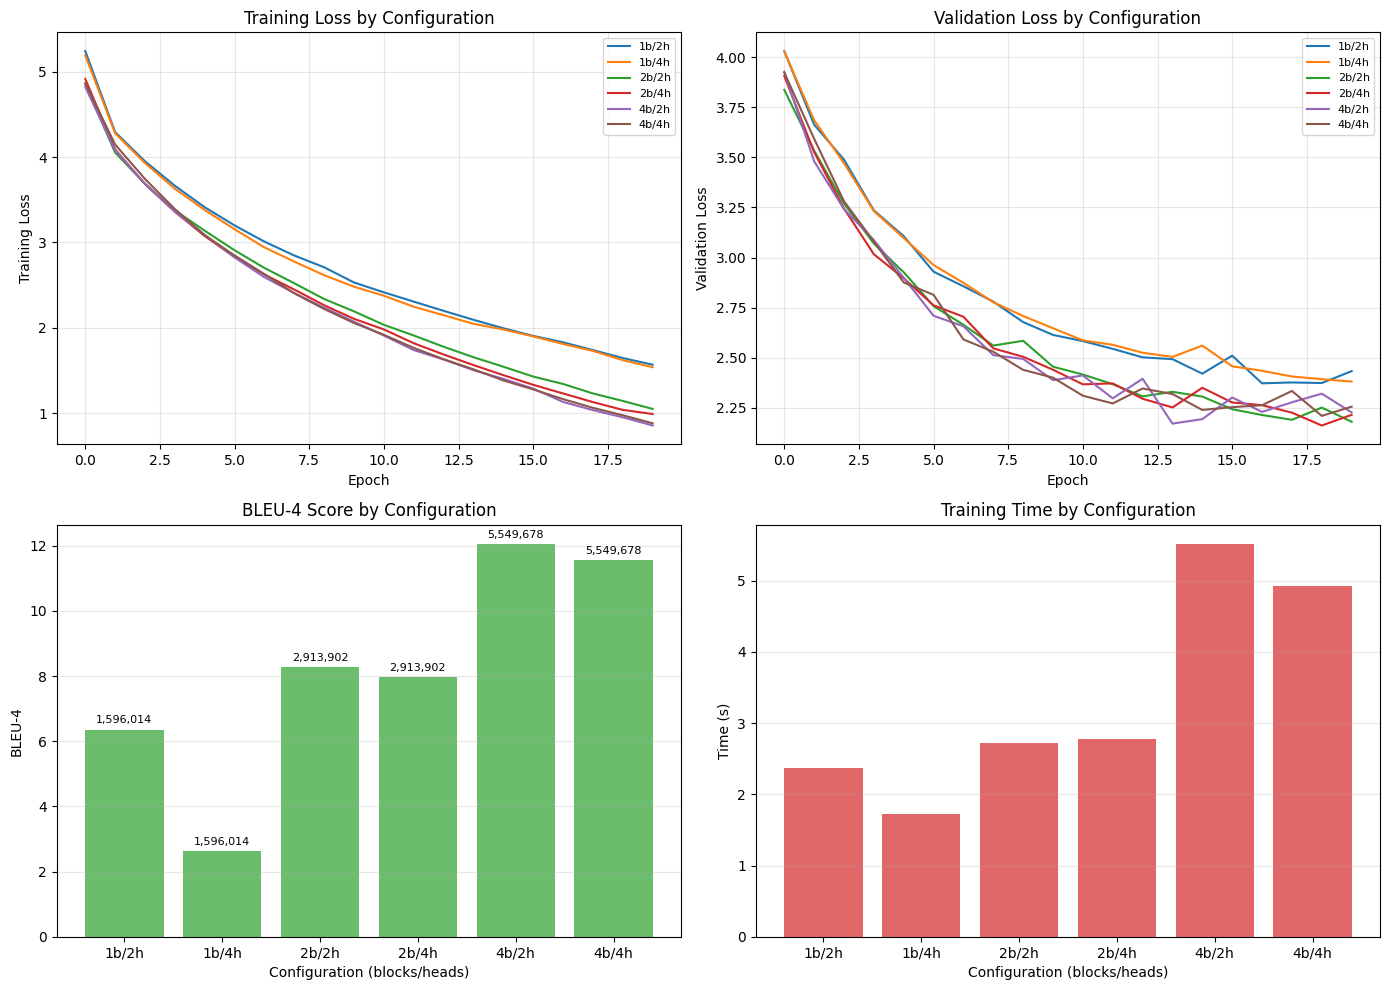


Best config by BLEU-4: 4 blocks, 2 heads — BLEU-4: 12.04


In [44]:
# 36: Comparison Table + Plots Across All Translation Configs

#  summary table
print(f"{'Blocks':<8}{'Heads':<8}{'Params':<12}{'Train Loss':<14}{'Val Loss':<12}{'Seq Acc%':<12}{'BLEU-4':<10}")
print("-" * 76)
for r in translation_sweep_results:
    h = r['history']
    print(f"{r['num_blocks']:<8}{r['num_heads']:<8}{r['num_params']:<12,}"
          f"{h['train_loss'][-1]:<14.4f}{h['val_loss'][-1]:<12.4f}"
          f"{r['seq_accuracy']:<12.2f}{r['bleu4']:<10.2f}")

# sort for consistent plotting order
sorted_trans_results = sorted(translation_sweep_results, key=lambda r: (r['num_blocks'], r['num_heads']))
trans_config_labels = [f"{r['num_blocks']}b/{r['num_heads']}h" for r in sorted_trans_results]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# subplot 1: training loss curves
ax = axes[0, 0]
for r, label in zip(sorted_trans_results, trans_config_labels):
    ax.plot(r['history']['train_loss'], label=label)
ax.set_title('Training Loss by Configuration')
ax.set_xlabel('Epoch')
ax.set_ylabel('Training Loss')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# validation loss curves
ax = axes[0, 1]
for r, label in zip(sorted_trans_results, trans_config_labels):
    ax.plot(r['history']['val_loss'], label=label)
ax.set_title('Validation Loss by Configuration')
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Loss')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# BLEU-4 by configuration (bar chart)
ax = axes[1, 0]
bleu_scores = [r['bleu4'] for r in sorted_trans_results]
params_list = [r['num_params'] for r in sorted_trans_results]
bars = ax.bar(trans_config_labels, bleu_scores, color='tab:green', alpha=0.7)
ax.set_title('BLEU-4 Score by Configuration')
ax.set_xlabel('Configuration (blocks/heads)')
ax.set_ylabel('BLEU-4')
ax.grid(True, alpha=0.3, axis='y')
for bar, params in zip(bars, params_list):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{params:,}', ha='center', fontsize=8)

# training time by configuration
ax = axes[1, 1]
times = [r['history']['total_time'] for r in sorted_trans_results]
ax.bar(trans_config_labels, times, color='tab:red', alpha=0.7)
ax.set_title('Training Time by Configuration')
ax.set_xlabel('Configuration (blocks/heads)')
ax.set_ylabel('Time (s)')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('problem3_sweep_comparison.png', dpi=150)
plt.show()

# identify best config by BLEU-4
best_trans_config = max(translation_sweep_results, key=lambda r: r['bleu4'])
print(f"\nBest config by BLEU-4: {best_trans_config['num_blocks']} blocks, "
      f"{best_trans_config['num_heads']} heads — BLEU-4: {best_trans_config['bleu4']:.2f}")

In [45]:
#  37: Qualitative Validation — Best Model Sample Translations

# use the best config by BLEU-4: 2 blocks, 4 heads
best_model = best_trans_config['model']

print("=" * 70)
print(f"Problem 3 — Best Transformer Config ({best_trans_config['num_blocks']} blocks, "
      f"{best_trans_config['num_heads']} heads): Sample Translations")
print("=" * 70)

# HW3 used: random.seed(42); random.sample(range(len(eng_val)), 5)
random.seed(42)
sample_indices = random.sample(range(len(eng_val)), 5)

for i, idx in enumerate(sample_indices):
    src_sent = eng_val[idx]   # original English sentence (tokenized)
    tgt_sent = fra_val[idx]   # correct French translation (tokenized)
    pred_sent = greedy_decode_transformer(best_model, src_sent, src_vocab, tgt_vocab)

    exact = "✓" if pred_sent == tgt_sent else "✗"
    bleu_score = sentence_bleu([tgt_sent], pred_sent, smoothing_function=smoothing) * 100

    print(f"\nExample {i+1}:")
    print(f"  English  : {' '.join(src_sent)}")
    print(f"  Target   : {' '.join(tgt_sent)}")
    print(f"  Predicted: {' '.join(pred_sent) if pred_sent else '[empty]'}")
    print(f"  Exact Match: {exact}  |  BLEU: {bleu_score:.2f}")

print("\n" + "=" * 70)

Problem 3 — Best Transformer Config (4 blocks, 2 heads): Sample Translations

Example 1:
  English  : the business hotel is situated near the center
  Target   : l'hôtel d'affaires est situé près du centre
  Predicted: la <unk> est <unk> <unk>
  Exact Match: ✗  |  BLEU: 3.60

Example 2:
  English  : he replies to all customer emails immediately
  Target   : il répond immédiatement à tous les e-mails des clients
  Predicted: il <unk> des <unk>
  Exact Match: ✗  |  BLEU: 2.74

Example 3:
  English  : i want a cold glass of iced coffee
  Target   : je veux un verre froid de café glacé
  Predicted: je veux une <unk> de <unk>
  Exact Match: ✗  |  BLEU: 6.85

Example 4:
  English  : i see a helicopter flying over the city
  Target   : je vois un hélicoptère voler au-dessus de la ville
  Predicted: j'ai une <unk> à <unk>
  Exact Match: ✗  |  BLEU: 0.00

Example 5:
  English  : he speaks six international languages completely fluently
  Target   : il parle couramment six langues internationale

In [46]:

#  38: Final Comparison — Best Transformer vs HW3 RNN Models

print("=" * 80)
print("Problem 3 Final Comparison: Transformer vs HW3 RNN Encoder-Decoder")
print("=" * 80)

print(f"\n{'Model':<25}{'Direction':<20}{'Params':<15}{'Seq Acc%':<12}{'BLEU-4':<10}")
print("-" * 82)
print(f"{'Baseline GRU (HW3)':<25}{'Eng->Fr':<20}{'5,889,134':<15}{'0.00':<12}{'3.52':<10}")
print(f"{'Attention GRU (HW3)':<25}{'Eng->Fr':<20}{'7,388,270':<15}{'0.00':<12}{'5.44':<10}")
print(f"{'Best Transformer':<25}{'Eng->Fr':<20}{best_trans_config['num_params']:<15,}"
      f"{best_trans_config['seq_accuracy']:<12.2f}{best_trans_config['bleu4']:<10.2f}")
print(f"  ({best_trans_config['num_blocks']} blocks, {best_trans_config['num_heads']} heads)")

# also show the full sweep for context, sorted by BLEU-4 descending
print(f"\n{'All Transformer Configs (sorted by BLEU-4):'}")
print(f"{'Blocks':<8}{'Heads':<8}{'Params':<12}{'BLEU-4':<10}")
for r in sorted(translation_sweep_results, key=lambda r: -r['bleu4']):
    print(f"{r['num_blocks']:<8}{r['num_heads']:<8}{r['num_params']:<12,}{r['bleu4']:<10.2f}")

# compute relative improvement over HW3's best RNN model
hw3_best_bleu = 5.44  # Attention GRU
improvement = ((best_trans_config['bleu4'] - hw3_best_bleu) / hw3_best_bleu) * 100
print(f"\nBest Transformer BLEU-4 ({best_trans_config['bleu4']:.2f}) vs HW3's best RNN "
      f"(Attention GRU, {hw3_best_bleu}): {improvement:+.1f}% relative change")

Problem 3 Final Comparison: Transformer vs HW3 RNN Encoder-Decoder

Model                    Direction           Params         Seq Acc%    BLEU-4    
----------------------------------------------------------------------------------
Baseline GRU (HW3)       Eng->Fr             5,889,134      0.00        3.52      
Attention GRU (HW3)      Eng->Fr             7,388,270      0.00        5.44      
Best Transformer         Eng->Fr             5,549,678      0.00        12.04     
  (4 blocks, 2 heads)

All Transformer Configs (sorted by BLEU-4):
Blocks  Heads   Params      BLEU-4    
4       2       5,549,678   12.04     
4       4       5,549,678   11.55     
2       2       2,913,902   8.27      
2       4       2,913,902   7.96      
1       2       1,596,014   6.35      
1       4       1,596,014   2.62      

Best Transformer BLEU-4 (12.04) vs HW3's best RNN (Attention GRU, 5.44): +121.3% relative change


In [47]:
#problem 4

In [48]:
# 39: Reversed Direction Setup (French to English)

# build reversed vocabularies on training data only ---
# French is now the source (what the encoder reads),
# English is now the target (what the decoder generates).
rev_src_vocab = Vocab()  # French vocabulary (now source)
rev_tgt_vocab = Vocab()  # English vocabulary (now target)
rev_src_vocab.build(fra_train)  # French sentences as source
rev_tgt_vocab.build(eng_train)  # English sentences as target

print(f"French (src) vocab size: {len(rev_src_vocab)}  |  English (tgt) vocab size: {len(rev_tgt_vocab)}")
# NOTE: Should match HW3's reported reversed vocab sizes: French 366, English 353.

# build reversed DataLoaders using the SAME TranslationDataset class from Cell 26
# just swap which list goes in as src_sents vs tgt_sents.
rev_collate_fn = make_translation_collate_fn(rev_src_vocab, rev_tgt_vocab)

rev_translation_train_loader = DataLoader(
    TranslationDataset(fra_train, eng_train, rev_src_vocab, rev_tgt_vocab),
    batch_size=TRANSLATION_BATCH_SIZE, shuffle=True, collate_fn=rev_collate_fn
)
rev_translation_val_loader = DataLoader(
    TranslationDataset(fra_val, eng_val, rev_src_vocab, rev_tgt_vocab),
    batch_size=TRANSLATION_BATCH_SIZE, shuffle=False, collate_fn=rev_collate_fn
)

print("Reversed (French -> English) DataLoaders ready.")

# inspect one batch \
rev_src_batch, rev_tgt_batch = next(iter(rev_translation_train_loader))
print(f"\nSource (French) batch shape: {rev_src_batch.shape}")
print(f"Target (English) batch shape: {rev_tgt_batch.shape}")

# decode one example to confirm direction is correctly swapped
print(f"\nExample source (French):  {decode_indices(rev_src_batch[0], rev_src_vocab)}")
print(f"Example target (English): {decode_indices(rev_tgt_batch[0], rev_tgt_vocab)}")

French (src) vocab size: 366  |  English (tgt) vocab size: 353
Reversed (French -> English) DataLoaders ready.

Source (French) batch shape: torch.Size([64, 12])
Target (English) batch shape: torch.Size([64, 11])

Example source (French):  je dois <unk> mon téléphone <eos> <pad> <pad> <pad> <pad> <pad> <pad>
Example target (English): <sos> i need to <unk> my phone <eos> <pad> <pad> <pad>


In [49]:
# 40a: Reversed Config Runner (French to English)

def run_reversed_translation_config(num_blocks, num_heads, embed_size=256, ff_hidden_size=512,
                                       num_epochs=20, learning_rate=0.0005, device=device,
                                       verbose_every=5, eval_max_len=50):
    """
    Same logic as run_translation_config (Cell 32), but explicitly uses the
    REVERSED vocabularies and DataLoaders (rev_src_vocab=French, rev_tgt_vocab=English)
    instead of the global Problem 3 ones, so we don't accidentally mix directions.
    """

    print(f"\n{'='*60}")
    print(f"Config: {num_blocks} blocks, {num_heads} heads (French -> English)")
    print(f"{'='*60}")

    model = Seq2SeqTransformer(
        src_vocab_size=len(rev_src_vocab),
        tgt_vocab_size=len(rev_tgt_vocab),
        embed_size=embed_size,
        num_heads=num_heads,
        num_blocks=num_blocks,
        ff_hidden_size=ff_hidden_size,
        dropout=0.1,
        src_pad_idx=rev_src_vocab.word2idx[PAD],
        tgt_pad_idx=rev_tgt_vocab.word2idx[PAD]
    ).to(device)

    num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Parameters: {num_params:,}")

    history = train_translation_model(
        model=model,
        train_loader=rev_translation_train_loader,
        val_loader=rev_translation_val_loader,
        tgt_vocab=rev_tgt_vocab,
        num_epochs=num_epochs,
        learning_rate=learning_rate,
        device=device,
        verbose_every=verbose_every
    )

    print("\nEvaluating on full validation set (Sequence Accuracy + BLEU-4)...")
    seq_accuracy, bleu4 = evaluate_translation_model(
        model, fra_val, eng_val, rev_src_vocab, rev_tgt_vocab, max_len=eval_max_len, device=device
    )
    print(f"Sequence Accuracy: {seq_accuracy:.2f}% | BLEU-4: {bleu4:.2f}")

    return {
        'num_blocks': num_blocks,
        'num_heads': num_heads,
        'num_params': num_params,
        'history': history,
        'seq_accuracy': seq_accuracy,
        'bleu4': bleu4,
        'model': model
    }

In [50]:
#  40: Reversed Translation Sweep — 1 Block (2 heads, 4 heads)

rev_translation_sweep_results = []

# config: 1 transformer block - 2 attention heads
rev_result_1b_2h = run_reversed_translation_config(
    num_blocks=1,
    num_heads=2,
    num_epochs=20,
    learning_rate=0.0005
)
rev_translation_sweep_results.append(rev_result_1b_2h)

# config: 1 transformer block -4 attention heads
rev_result_1b_4h = run_reversed_translation_config(
    num_blocks=1,
    num_heads=4,
    num_epochs=20,
    learning_rate=0.0005
)
rev_translation_sweep_results.append(rev_result_1b_4h)

print("\n" + "="*60)
print(f"Cell 40 complete: {len(rev_translation_sweep_results)}/6 configs done")
print("="*60)


Config: 1 blocks, 2 heads (French -> English)
Parameters: 1,592,673
Epoch 01/20 | Train Loss: 5.1286 | Val Loss: 3.8184 | Elapsed: 0.1s
Epoch 05/20 | Train Loss: 3.2389 | Val Loss: 3.0071 | Elapsed: 0.4s
Epoch 10/20 | Train Loss: 2.4211 | Val Loss: 2.6026 | Elapsed: 0.9s
Epoch 15/20 | Train Loss: 1.9206 | Val Loss: 2.4033 | Elapsed: 1.3s
Epoch 20/20 | Train Loss: 1.5119 | Val Loss: 2.2973 | Elapsed: 1.8s

Training complete in 1.77s
Final Train Loss: 1.5119 | Final Val Loss: 2.2973

Evaluating on full validation set (Sequence Accuracy + BLEU-4)...
Sequence Accuracy: 0.00% | BLEU-4: 5.03

Config: 1 blocks, 4 heads (French -> English)
Parameters: 1,592,673
Epoch 01/20 | Train Loss: 5.1646 | Val Loss: 3.8717 | Elapsed: 0.1s
Epoch 05/20 | Train Loss: 3.3154 | Val Loss: 3.0390 | Elapsed: 0.4s
Epoch 10/20 | Train Loss: 2.4923 | Val Loss: 2.6540 | Elapsed: 0.9s
Epoch 15/20 | Train Loss: 1.9577 | Val Loss: 2.4341 | Elapsed: 1.3s
Epoch 20/20 | Train Loss: 1.5161 | Val Loss: 2.3227 | Elapsed: 1.

In [51]:

# CELL 41: Reversed Translation Sweep — 2 Blocks (2 heads, 4 heads)


rev_result_2b_2h = run_reversed_translation_config(
    num_blocks=2,
    num_heads=2,
    num_epochs=20,
    learning_rate=0.0005
)
rev_translation_sweep_results.append(rev_result_2b_2h)

rev_result_2b_4h = run_reversed_translation_config(
    num_blocks=2,
    num_heads=4,
    num_epochs=20,
    learning_rate=0.0005
)
rev_translation_sweep_results.append(rev_result_2b_4h)

print("\n" + "="*60)
print(f"Cell 41 complete: {len(rev_translation_sweep_results)}/6 configs done")
print("="*60)


Config: 2 blocks, 2 heads (French -> English)
Parameters: 2,910,561
Epoch 01/20 | Train Loss: 4.8100 | Val Loss: 3.6921 | Elapsed: 0.1s
Epoch 05/20 | Train Loss: 2.9626 | Val Loss: 2.7690 | Elapsed: 0.7s
Epoch 10/20 | Train Loss: 2.0072 | Val Loss: 2.2485 | Elapsed: 1.4s
Epoch 15/20 | Train Loss: 1.3965 | Val Loss: 2.1853 | Elapsed: 2.1s
Epoch 20/20 | Train Loss: 0.9085 | Val Loss: 2.2375 | Elapsed: 2.8s

Training complete in 2.76s
Final Train Loss: 0.9085 | Final Val Loss: 2.2375

Evaluating on full validation set (Sequence Accuracy + BLEU-4)...
Sequence Accuracy: 0.00% | BLEU-4: 10.58

Config: 2 blocks, 4 heads (French -> English)
Parameters: 2,910,561
Epoch 01/20 | Train Loss: 4.7596 | Val Loss: 3.6800 | Elapsed: 0.1s
Epoch 05/20 | Train Loss: 2.9364 | Val Loss: 2.7173 | Elapsed: 0.7s
Epoch 10/20 | Train Loss: 2.0077 | Val Loss: 2.3156 | Elapsed: 1.4s
Epoch 15/20 | Train Loss: 1.4327 | Val Loss: 2.1269 | Elapsed: 2.1s
Epoch 20/20 | Train Loss: 0.9110 | Val Loss: 2.1083 | Elapsed: 2

In [52]:
# 42: Reversed Translation Sweep — 4 Blocks (2 heads, 4 heads)

rev_result_4b_2h = run_reversed_translation_config(
    num_blocks=4,
    num_heads=2,
    num_epochs=20,
    learning_rate=0.0005
)
rev_translation_sweep_results.append(rev_result_4b_2h)

rev_result_4b_4h = run_reversed_translation_config(
    num_blocks=4,
    num_heads=4,
    num_epochs=20,
    learning_rate=0.0005
)
rev_translation_sweep_results.append(rev_result_4b_4h)

print("\n" + "="*60)
print(f"Cell 42 complete: {len(rev_translation_sweep_results)}/6 configs done — full sweep finished!")
print("="*60)


Config: 4 blocks, 2 heads (French -> English)
Parameters: 5,546,337
Epoch 01/20 | Train Loss: 4.7137 | Val Loss: 3.7044 | Elapsed: 0.3s
Epoch 05/20 | Train Loss: 2.9685 | Val Loss: 2.7412 | Elapsed: 1.3s
Epoch 10/20 | Train Loss: 1.9726 | Val Loss: 2.2462 | Elapsed: 2.5s
Epoch 15/20 | Train Loss: 1.3252 | Val Loss: 2.1975 | Elapsed: 3.7s
Epoch 20/20 | Train Loss: 0.8217 | Val Loss: 1.9569 | Elapsed: 4.9s

Training complete in 4.92s
Final Train Loss: 0.8217 | Final Val Loss: 1.9569

Evaluating on full validation set (Sequence Accuracy + BLEU-4)...
Sequence Accuracy: 0.00% | BLEU-4: 6.78

Config: 4 blocks, 4 heads (French -> English)
Parameters: 5,546,337
Epoch 01/20 | Train Loss: 4.7434 | Val Loss: 3.7105 | Elapsed: 0.3s
Epoch 05/20 | Train Loss: 2.9226 | Val Loss: 2.7261 | Elapsed: 1.4s
Epoch 10/20 | Train Loss: 1.8942 | Val Loss: 2.3479 | Elapsed: 2.7s
Epoch 15/20 | Train Loss: 1.2753 | Val Loss: 2.0935 | Elapsed: 3.9s
Epoch 20/20 | Train Loss: 0.8480 | Val Loss: 2.1478 | Elapsed: 5.

Blocks  Heads   Params      Train Loss    Val Loss    Seq Acc%    BLEU-4    
----------------------------------------------------------------------------
1       2       1,592,673   1.5119        2.2973      0.00        5.03      
1       4       1,592,673   1.5161        2.3227      0.00        2.83      
2       2       2,910,561   0.9085        2.2375      0.00        10.58     
2       4       2,910,561   0.9110        2.1083      0.00        10.00     
4       2       5,546,337   0.8217        1.9569      0.00        6.78      
4       4       5,546,337   0.8480        2.1478      0.00        11.80     


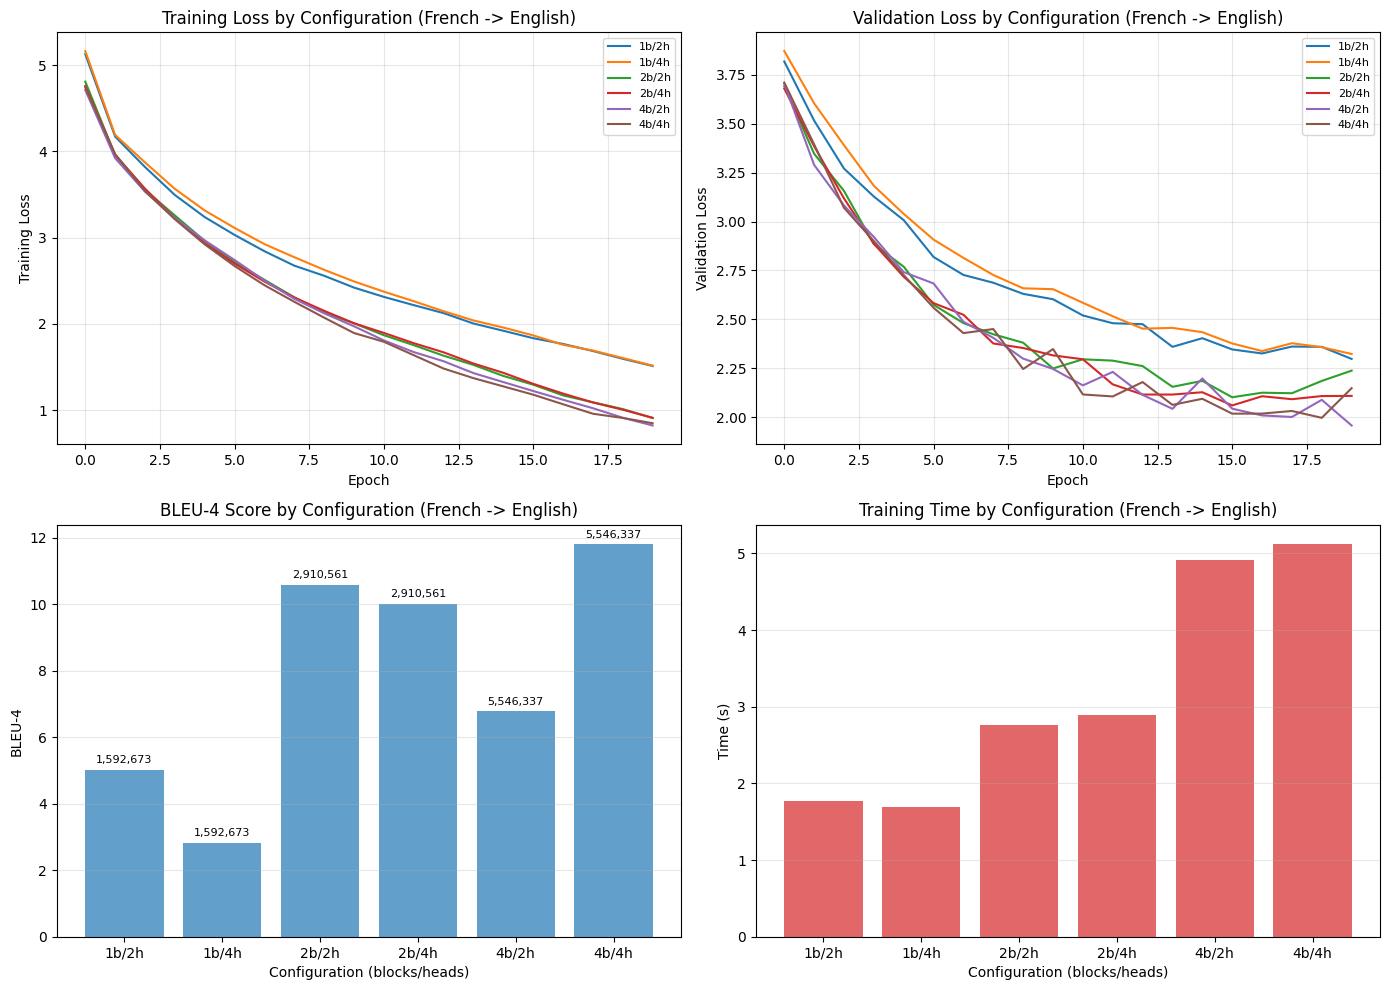


Best reversed config by BLEU-4: 4 blocks, 4 heads — BLEU-4: 11.80


In [53]:
# 43: Reversed Direction — Comparison Table + Plots

print(f"{'Blocks':<8}{'Heads':<8}{'Params':<12}{'Train Loss':<14}{'Val Loss':<12}{'Seq Acc%':<12}{'BLEU-4':<10}")
print("-" * 76)
for r in rev_translation_sweep_results:
    h = r['history']
    print(f"{r['num_blocks']:<8}{r['num_heads']:<8}{r['num_params']:<12,}"
          f"{h['train_loss'][-1]:<14.4f}{h['val_loss'][-1]:<12.4f}"
          f"{r['seq_accuracy']:<12.2f}{r['bleu4']:<10.2f}")

sorted_rev_results = sorted(rev_translation_sweep_results, key=lambda r: (r['num_blocks'], r['num_heads']))
rev_config_labels = [f"{r['num_blocks']}b/{r['num_heads']}h" for r in sorted_rev_results]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
for r, label in zip(sorted_rev_results, rev_config_labels):
    ax.plot(r['history']['train_loss'], label=label)
ax.set_title('Training Loss by Configuration (French -> English)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Training Loss')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
for r, label in zip(sorted_rev_results, rev_config_labels):
    ax.plot(r['history']['val_loss'], label=label)
ax.set_title('Validation Loss by Configuration (French -> English)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Loss')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
bleu_scores = [r['bleu4'] for r in sorted_rev_results]
params_list = [r['num_params'] for r in sorted_rev_results]
bars = ax.bar(rev_config_labels, bleu_scores, color='tab:blue', alpha=0.7)
ax.set_title('BLEU-4 Score by Configuration (French -> English)')
ax.set_xlabel('Configuration (blocks/heads)')
ax.set_ylabel('BLEU-4')
ax.grid(True, alpha=0.3, axis='y')
for bar, params in zip(bars, params_list):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{params:,}', ha='center', fontsize=8)

ax = axes[1, 1]
times = [r['history']['total_time'] for r in sorted_rev_results]
ax.bar(rev_config_labels, times, color='tab:red', alpha=0.7)
ax.set_title('Training Time by Configuration (French -> English)')
ax.set_xlabel('Configuration (blocks/heads)')
ax.set_ylabel('Time (s)')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('problem4_sweep_comparison.png', dpi=150)
plt.show()

best_rev_config = max(rev_translation_sweep_results, key=lambda r: r['bleu4'])
print(f"\nBest reversed config by BLEU-4: {best_rev_config['num_blocks']} blocks, "
      f"{best_rev_config['num_heads']} heads — BLEU-4: {best_rev_config['bleu4']:.2f}")

In [54]:
# 44: Qualitative Validation — Best Reversed Model (French to English)

best_rev_model = best_rev_config['model']

print("=" * 70)
print(f"Problem 4 — Best Transformer Config ({best_rev_config['num_blocks']} blocks, "
      f"{best_rev_config['num_heads']} heads): Sample Translations (French -> English)")
print("=" * 70)

# --- Use the SAME 5 sample indices as Problem 3 / HW3, for direct comparability ---
random.seed(42)
sample_indices_rev = random.sample(range(len(eng_val)), 5)

for i, idx in enumerate(sample_indices_rev):
    src_sent = fra_val[idx]   # French sentence (now the source)
    tgt_sent = eng_val[idx]   # English target
    pred_sent = greedy_decode_transformer(best_rev_model, src_sent, rev_src_vocab, rev_tgt_vocab)

    exact = "✓" if pred_sent == tgt_sent else "✗"
    bleu_score = sentence_bleu([tgt_sent], pred_sent, smoothing_function=smoothing) * 100

    print(f"\nExample {i+1}:")
    print(f"  French   : {' '.join(src_sent)}")
    print(f"  Target   : {' '.join(tgt_sent)}")
    print(f"  Predicted: {' '.join(pred_sent) if pred_sent else '[empty]'}")
    print(f"  Exact Match: {exact}  |  BLEU: {bleu_score:.2f}")

print("\n" + "=" * 70)

Problem 4 — Best Transformer Config (4 blocks, 4 heads): Sample Translations (French -> English)

Example 1:
  French   : l'hôtel d'affaires est situé près du centre
  Target   : the business hotel is situated near the center
  Predicted: the <unk> is <unk> in <unk>
  Exact Match: ✗  |  BLEU: 3.48

Example 2:
  French   : il répond immédiatement à tous les e-mails des clients
  Target   : he replies to all customer emails immediately
  Predicted: he answers <unk> the <unk>
  Exact Match: ✗  |  BLEU: 3.60

Example 3:
  French   : je veux un verre froid de café glacé
  Target   : i want a cold glass of iced coffee
  Predicted: i want to drink a new pair of coffee
  Exact Match: ✗  |  BLEU: 6.38

Example 4:
  French   : je vois un hélicoptère voler au-dessus de la ville
  Target   : i see a helicopter flying over the city
  Predicted: i see a <unk> in the sky
  Exact Match: ✗  |  BLEU: 15.23

Example 5:
  French   : il parle couramment six langues internationales
  Target   : he speaks si

In [55]:
#45: Final Comparison

print("=" * 90)
print("Final Comparison: Transformer vs HW3 RNN Encoder-Decoder (Both Directions)")
print("=" * 90)

print(f"\n{'Model':<25}{'Direction':<15}{'Params':<15}{'Seq Acc%':<12}{'BLEU-4':<10}")
print("-" * 77)
print(f"{'Baseline GRU (HW3)':<25}{'Eng->Fr':<15}{'5,889,134':<15}{'0.00':<12}{'3.52':<10}")
print(f"{'Attention GRU (HW3)':<25}{'Eng->Fr':<15}{'7,388,270':<15}{'0.00':<12}{'5.44':<10}")
print(f"{'Best Transformer':<25}{'Eng->Fr':<15}{best_trans_config['num_params']:<15,}"
      f"{best_trans_config['seq_accuracy']:<12.2f}{best_trans_config['bleu4']:<10.2f}")
print(f"  ({best_trans_config['num_blocks']}b/{best_trans_config['num_heads']}h)")
print()
print(f"{'Baseline GRU (HW3)':<25}{'Fr->Eng':<15}{'5,889,134':<15}{'0.00':<12}{'1.32':<10}")
print(f"{'Attention GRU (HW3)':<25}{'Fr->Eng':<15}{'7,388,270':<15}{'0.00':<12}{'8.87':<10}")
print(f"{'Best Transformer':<25}{'Fr->Eng':<15}{best_rev_config['num_params']:<15,}"
      f"{best_rev_config['seq_accuracy']:<12.2f}{best_rev_config['bleu4']:<10.2f}")
print(f"  ({best_rev_config['num_blocks']}b/{best_rev_config['num_heads']}h)")

# relative improvements over HW3s best RNN in each direction
eng_fr_improvement = ((best_trans_config['bleu4'] - 5.44) / 5.44) * 100
fr_eng_improvement = ((best_rev_config['bleu4'] - 8.87) / 8.87) * 100

print(f"\nEng->Fr: Transformer ({best_trans_config['bleu4']:.2f}) vs HW3 Attention GRU (5.44): "
      f"{eng_fr_improvement:+.1f}%")
print(f"Fr->Eng: Transformer ({best_rev_config['bleu4']:.2f}) vs HW3 Attention GRU (8.87): "
      f"{fr_eng_improvement:+.1f}%")

# compare transformer's two directions against each other
print(f"\nTransformer BLEU-4 — Eng->Fr: {best_trans_config['bleu4']:.2f} | "
      f"Fr->Eng: {best_rev_config['bleu4']:.2f}")
direction_diff = best_rev_config['bleu4'] - best_trans_config['bleu4']
print(f"Difference (Fr->Eng minus Eng->Fr): {direction_diff:+.2f} BLEU points")

Final Comparison: Transformer vs HW3 RNN Encoder-Decoder (Both Directions)

Model                    Direction      Params         Seq Acc%    BLEU-4    
-----------------------------------------------------------------------------
Baseline GRU (HW3)       Eng->Fr        5,889,134      0.00        3.52      
Attention GRU (HW3)      Eng->Fr        7,388,270      0.00        5.44      
Best Transformer         Eng->Fr        5,549,678      0.00        12.04     
  (4b/2h)

Baseline GRU (HW3)       Fr->Eng        5,889,134      0.00        1.32      
Attention GRU (HW3)      Fr->Eng        7,388,270      0.00        8.87      
Best Transformer         Fr->Eng        5,546,337      0.00        11.80     
  (4b/4h)

Eng->Fr: Transformer (12.04) vs HW3 Attention GRU (5.44): +121.3%
Fr->Eng: Transformer (11.80) vs HW3 Attention GRU (8.87): +33.0%

Transformer BLEU-4 — Eng->Fr: 12.04 | Fr->Eng: 11.80
Difference (Fr->Eng minus Eng->Fr): -0.24 BLEU points
